# NBA Trajectory DCGAN — Kaggle mask pipeline

**Task 4.** GAN генерирует NBA trajectory maps.

Модель учит только 1-channel grayscale/binary mask траектории. Корт не генерируется GAN-ом, а добавляется отдельно после генерации для визуализации: белый фон, серый корт, чёрная траектория.

Эта версия рассчитана на **Kaggle Notebook**: данные берутся из `/kaggle/input`, результаты сохраняются в `/kaggle/working`.


## Блок импортов и настройки окружения

Здесь собраны зависимости, seed, устройство и Kaggle-пути. Датасет должен быть добавлен через **Add Data** в правой панели Kaggle.


In [1]:
### ====================== Импорты ======================
import os, sys, json, time, csv, zipfile, random, shutil, math
from copy import deepcopy
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.utils import make_grid, save_image

from PIL import Image, ImageDraw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

### ====================== Воспроизводимость ======================
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

### ====================== Dataset / run mode config ======================
SMOKE_TEST = False
FAST_DEBUG = True
RUN_MASK_GAN_BASELINE = True
RUN_COORD_GAN = True
RUN_COORD_VAE = True

FULL_TRAIN_IMAGES = 200_000
FULL_TEST_IMAGES = 5_000
FAST_TRAIN_IMAGES = 50_000
FAST_TEST_IMAGES = 1_000
SMOKE_TRAIN_IMAGES = 512
SMOKE_TEST_IMAGES = 128

FULL_BATCH_SIZE = 128
FAST_BATCH_SIZE = 128
SMOKE_BATCH_SIZE = 128
SMOKE_MAX_BATCHES = 2
SMOKE_EPOCHS = 2

COORD_NUM_POINTS = 50
COORD_BATCH_SIZE = 256
COORD_BATCH_SIZE_FALLBACK = 128
COORD_LATENT_DIM = 32
COORD_Z_DIM = 32
COORD_VAE_BETA = 0.001
COORD_LR_VAE = 1e-3
COORD_LR_G = 1e-4
COORD_LR_D = 1e-4

if SMOKE_TEST:
    RUN_MODE = "SMOKE_TEST"
elif FAST_DEBUG:
    RUN_MODE = "FAST_DEBUG"
else:
    RUN_MODE = "FULL"
print("RUN_MODE:", RUN_MODE)
print("RUN_MASK_GAN_BASELINE:", RUN_MASK_GAN_BASELINE)
print("RUN_COORD_GAN:", RUN_COORD_GAN)
print("RUN_COORD_VAE:", RUN_COORD_VAE)

### ====================== Устройство ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
GPU_NAME = torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU"
print("GPU:", GPU_NAME)
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

### ====================== GPU training preset ======================
NUM_WORKERS = 2
PIN_MEMORY = (device.type == "cuda")
if "P100" in GPU_NAME:
    GPU_PRESET = "P100_FP32_RECOMMENDED"
elif "T4" in GPU_NAME:
    GPU_PRESET = "T4_OK_FP32"
else:
    GPU_PRESET = "DEFAULT"
print("GPU_PRESET:", GPU_PRESET)

### ====================== Пути Kaggle ======================
KAGGLE_INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working")
EXTRACT_DIR = WORK / "extracted_data"

DATA_ROOT = None

DATA_DIR = WORK / "data"
CKPT_DIR = WORK / "checkpoints"
SAMPLES_DIR = WORK / "samples"
LOG_DIR = WORK / "logs"
GEN_DIR = WORK / "generated"

for d in (WORK, EXTRACT_DIR, DATA_DIR, CKPT_DIR, SAMPLES_DIR, LOG_DIR, GEN_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("WORK:", WORK)
print("KAGGLE_INPUT:", KAGGLE_INPUT)


RUN_MODE: FAST_DEBUG
RUN_MASK_GAN_BASELINE: True
RUN_COORD_GAN: True
RUN_COORD_VAE: True
device: cuda
GPU: Tesla T4
GPU_PRESET: T4_OK_FP32
WORK: /kaggle/working
KAGGLE_INPUT: /kaggle/input


## Stage 0 — загрузка данных на Kaggle

Перед запуском добавь датасет через **Add Data**.

Ячейка ниже умеет:

- использовать готовую папку с PNG в `/kaggle/input/...`;
- рекурсивно искать PNG во вложенных папках;
- если в input лежит zip-архив, распаковать его в `/kaggle/working/extracted_data`;
- вывести диагностику `DATA_ROOT`, число PNG и первые файлы.


In [2]:
CLEAR_PREVIOUS_OUTPUTS = True
AUTO_EXTRACT_ZIP = True

# ВАЖНО:
# Сбрасываем DATA_ROOT, чтобы не использовать старый неправильный путь из памяти ноутбука.
DATA_ROOT = None


def clear_previous_outputs():
    """
    Очищает старые артефакты в /kaggle/working,
    но НЕ трогает /kaggle/input и НЕ удаляет data/extracted_data.
    """
    keep = {"data", "extracted_data"}
    removed = []

    for entry in WORK.iterdir():
        if entry.name in keep:
            continue

        if entry.is_dir():
            shutil.rmtree(entry)
        else:
            entry.unlink()

        removed.append(entry.name)

    for d in (DATA_DIR, CKPT_DIR, SAMPLES_DIR, LOG_DIR, GEN_DIR, EXTRACT_DIR):
        d.mkdir(parents=True, exist_ok=True)

    print("Очищены старые артефакты:", sorted(removed) or "ничего", flush=True)


def find_png_files(root):
    """
    Быстрый рекурсивный поиск PNG.
    """
    root = Path(root)

    if not root.exists():
        print(f"Папка не существует: {root}", flush=True)
        return []

    print(f"Сканирую PNG в: {root}", flush=True)

    files = sorted(root.rglob("*.png"))

    print(f"PNG найдено: {len(files):,}", flush=True)

    return files


def find_candidate_data_roots():
    """
    Ищет папки в /kaggle/input, где есть PNG.
    """
    candidates = []

    print("Ищу candidate data roots в /kaggle/input ...", flush=True)

    for child in sorted(KAGGLE_INPUT.iterdir()):
        if not child.is_dir():
            continue

        print(f"\nПроверяю input-папку: {child}", flush=True)

        png_files = find_png_files(child)
        n_png = len(png_files)

        print(f"Найдено PNG в {child.name}: {n_png:,}", flush=True)

        if n_png > 0:
            candidates.append((n_png, child, png_files))

    candidates = sorted(candidates, key=lambda x: x[0], reverse=True)

    if candidates:
        print("\nНайдены кандидаты:", flush=True)
        for n_png, path, _ in candidates:
            print(f"- {path} | PNG: {n_png:,}", flush=True)
    else:
        print("PNG-кандидаты не найдены в /kaggle/input.", flush=True)

    return candidates


def extract_first_zip_if_needed():
    """
    Если Add Data дал zip, распаковываем первый zip из /kaggle/input
    в /kaggle/working/extracted_data с прогресс-баром.
    """
    print("Ищу ZIP в /kaggle/input ...", flush=True)

    zip_files = sorted(KAGGLE_INPUT.rglob("*.zip"))

    if not zip_files:
        print("ZIP не найден.", flush=True)
        return None

    print("Найдены ZIP:", flush=True)

    for z in zip_files[:10]:
        size_gb = z.stat().st_size / (1024 ** 3)
        print(f"- {z} | {size_gb:.2f} GB", flush=True)

    if len(zip_files) > 10:
        print(f"... и ещё {len(zip_files) - 10} zip-файлов", flush=True)

    zip_path = zip_files[0]

    print("\nPNG не найдены в папках. Распаковываем первый ZIP:", zip_path, flush=True)

    if EXTRACT_DIR.exists():
        print("Удаляю старую extracted_data ...", flush=True)
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.infolist()
        total_size = sum(m.file_size for m in members)

        print(f"Файлов в ZIP: {len(members):,}", flush=True)
        print(f"Размер распакованных данных: {total_size / (1024 ** 3):.2f} GB", flush=True)

        with tqdm(
            total=total_size,
            unit="B",
            unit_scale=True,
            desc="Распаковка ZIP",
        ) as pbar:
            for member in members:
                zf.extract(member, EXTRACT_DIR)
                pbar.update(member.file_size)

    print("Распаковка завершена:", EXTRACT_DIR, flush=True)

    return EXTRACT_DIR


# ====================== Основной запуск ячейки ======================

if CLEAR_PREVIOUS_OUTPUTS:
    clear_previous_outputs()

print("=" * 100, flush=True)
print("KAGGLE_INPUT:", KAGGLE_INPUT, flush=True)
print("WORK:", WORK, flush=True)
print("SMOKE_TEST:", SMOKE_TEST, flush=True)
print("AUTO_EXTRACT_ZIP:", AUTO_EXTRACT_ZIP, flush=True)
print("=" * 100, flush=True)

print("Содержимое /kaggle/input:", flush=True)
for p in sorted(KAGGLE_INPUT.iterdir()):
    print("-", p, flush=True)

# Явные кандидаты под разные варианты названия Kaggle Dataset
preferred_roots = [
    KAGGLE_INPUT / "trajectories",
    KAGGLE_INPUT / "trajectory",
    KAGGLE_INPUT / "datasets",
    KAGGLE_INPUT / "datasets" / "trajectories",
    KAGGLE_INPUT / "datasets" / "olegsadykhov" / "nba-trajectories-128x64",
    KAGGLE_INPUT / "nba-trajectories-128x64",
]

all_files = []
DATA_ROOT = None

# 1) Сначала проверяем явные пути
for root in preferred_roots:
    if not root.exists():
        continue

    print(f"\nПробую DATA_ROOT: {root}", flush=True)

    png_files = find_png_files(root)

    if len(png_files) > 0:
        DATA_ROOT = root
        all_files = png_files

        print("\nВыбран DATA_ROOT:", DATA_ROOT, flush=True)
        print("PNG в выбранной папке:", f"{len(all_files):,}", flush=True)

        break

# 2) Если явные пути не помогли — ищем любой input с PNG
if not all_files:
    candidates = find_candidate_data_roots()

    if candidates:
        n_png, DATA_ROOT, all_files = candidates[0]

        print("\nАвтовыбран DATA_ROOT:", DATA_ROOT, flush=True)
        print("PNG в выбранной папке:", f"{n_png:,}", flush=True)

# 3) Если PNG не нашли, но есть ZIP — распаковываем
if not all_files and AUTO_EXTRACT_ZIP:
    extracted = extract_first_zip_if_needed()

    if extracted is not None:
        DATA_ROOT = extracted

        print("\nСканирую распакованную папку:", DATA_ROOT, flush=True)
        all_files = find_png_files(DATA_ROOT)

ALL_PNG_FILES = all_files

print("=" * 100, flush=True)
print("ИТОГ:", flush=True)
print("DATA_ROOT:", DATA_ROOT, flush=True)
print("all png files:", f"{len(all_files):,}", flush=True)

if len(all_files) > 0:
    print("first files:", all_files[:5], flush=True)
    print("last file:", all_files[-1], flush=True)

print("=" * 100, flush=True)

if len(all_files) == 0:
    raise RuntimeError(
        "PNG не найдены. Проверь Kaggle Add Data и путь к датасету."
    )

if len(all_files) < 10_000 and not SMOKE_TEST:
    raise RuntimeError(
        "Найдено слишком мало PNG для full training. "
        "Проверь DATA_ROOT, Kaggle Add Data или распаковку датасета. "
        f"Сейчас найдено только {len(all_files)} PNG."
    )

Очищены старые артефакты: ['.virtual_documents', 'checkpoints', 'generated', 'logs', 'samples']
KAGGLE_INPUT: /kaggle/input
WORK: /kaggle/working
SMOKE_TEST: False
AUTO_EXTRACT_ZIP: True
Содержимое /kaggle/input:
- /kaggle/input/datasets

Пробую DATA_ROOT: /kaggle/input/datasets
Сканирую PNG в: /kaggle/input/datasets
PNG найдено: 578,563

Выбран DATA_ROOT: /kaggle/input/datasets
PNG в выбранной папке: 578,563
ИТОГ:
DATA_ROOT: /kaggle/input/datasets
all png files: 578,563
first files: [PosixPath('/kaggle/input/datasets/kirillstulov/trajectories/0021500001_e105_p200757.png'), PosixPath('/kaggle/input/datasets/kirillstulov/trajectories/0021500001_e105_p201143.png'), PosixPath('/kaggle/input/datasets/kirillstulov/trajectories/0021500001_e105_p201168.png'), PosixPath('/kaggle/input/datasets/kirillstulov/trajectories/0021500001_e105_p203471.png'), PosixPath('/kaggle/input/datasets/kirillstulov/trajectories/0021500001_e105_p203934.png')]
last file: /kaggle/input/datasets/kirillstulov/trajecto

## Stage 1 — split train/test

Файлы делятся по `game_id`, чтобы траектории из одного матча не попадали одновременно в train и held-out test/val. Если имя файла не содержит `_e`, используется часть имени до первого `_`.


In [3]:
TEST_FRACTION = 0.15
TRAIN_LIST = WORK / "train_files.txt"
TEST_LIST = WORK / "test_files.txt"


def game_id_from_path(p):
    stem = Path(p).stem
    if "_e" in stem:
        gid = stem.split("_e")[0]
        return gid if gid else None
    return None


def split_png_files(png_files):
    png_files = [Path(p) for p in png_files]
    if not png_files:
        raise RuntimeError("Список PNG пустой. Проверь загрузку/распаковку архива.")

    by_game = {}
    missing_gid = 0
    for p in png_files:
        gid = game_id_from_path(p)
        if gid is None:
            missing_gid += 1
            continue
        by_game.setdefault(gid, []).append(p)

    use_game_split = len(by_game) >= 2 and missing_gid < len(png_files)
    rng = random.Random(SEED)

    if use_game_split:
        games = sorted(by_game.keys())
        rng.shuffle(games)
        n_test_games = max(1, round(len(games) * TEST_FRACTION))
        test_games = set(games[:n_test_games])
        train_games = set(games[n_test_games:])
        train_files = [p for g in train_games for p in by_game[g]]
        test_files = [p for g in test_games for p in by_game[g]]
        print(f"game_id split: train_games={len(train_games)}, test_games={len(test_games)}, missing_gid={missing_gid}")
    else:
        print("WARNING: game_id split невозможен, используем random split по файлам.")
        shuffled = list(png_files)
        rng.shuffle(shuffled)
        n_test = max(1, round(len(shuffled) * TEST_FRACTION))
        test_files = shuffled[:n_test]
        train_files = shuffled[n_test:]

    rng.shuffle(train_files)
    rng.shuffle(test_files)
    print(f"split before limit: train={len(train_files)}, test={len(test_files)}")

    if SMOKE_TEST:
        train_files = train_files[:SMOKE_TRAIN_IMAGES]
        test_files = test_files[:SMOKE_TEST_IMAGES]
    elif FAST_DEBUG:
        train_files = train_files[:FAST_TRAIN_IMAGES]
        test_files = test_files[:FAST_TEST_IMAGES]
    else:
        train_files = train_files[:FULL_TRAIN_IMAGES]
        test_files = test_files[:FULL_TEST_IMAGES]

    return train_files, test_files


def copy_train_to_work(train_source_files):
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    def _copy_one(item):
        idx, src = item
        dst = DATA_DIR / src.name
        if dst.exists():
            dst = DATA_DIR / f"{idx:06d}_{src.name}"
        shutil.copy(src, dst)
        return dst

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as ex:
        train_local = list(tqdm(ex.map(_copy_one, enumerate(train_source_files)), total=len(train_source_files), desc="copy train"))
    print(f"Копирование train в /kaggle/working/data: {(time.time()-t0):.1f}s")
    return train_local


train_source_files, test_files = split_png_files(all_files)
train_files = copy_train_to_work(train_source_files)

TRAIN_LIST.write_text("\n".join(str(p) for p in train_files), encoding="utf-8")
TEST_LIST.write_text("\n".join(str(p) for p in test_files), encoding="utf-8")

print("train images =", len(train_files))
print("test images =", len(test_files))

if not SMOKE_TEST and len(train_files) < 10_000:
    raise RuntimeError(f"Expected normal GPU training data, got {len(train_files)} train images. Data loading is broken.")


game_id split: train_games=536, test_games=95, missing_gid=0
split before limit: train=490482, test=88081


copy train:   0%|          | 0/50000 [00:00<?, ?it/s]

Копирование train в /kaggle/working/data: 81.7s
train images = 50000
test images = 1000


## Stage 2 — `Dataset` и `DataLoader`

`Dataset` теперь возвращает **1-channel mask** `[1, 64, 128]`, а не RGB-картинку с кортом.

Что изменено:

- исходный PNG читается как grayscale;
- тёмные пиксели выделяются как траектория;
- фон корта отбрасывается, потому что он светло-серый/белый и не проходит threshold;
- реальная маска бинаризуется в формате: белый фон = `+1`, чёрная траектория = `-1`.

Так GAN учит только геометрию траектории, а корт добавляется отдельно в визуализации.


train images = 50000
test images = 1000
batch_size = 128
batches per epoch = 391
батчей в эпохе = 391
batch shape: (128, 1, 64, 128)
min/max: -1.0 1.0
real black pixel ratio in batch: 0.0471


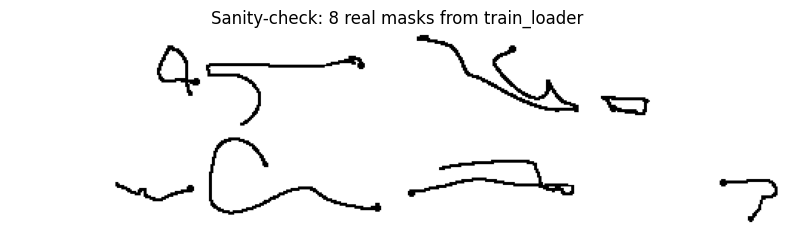

In [4]:
IMG_W, IMG_H = 128, 64

### Real mask extraction.
LINE_THRESHOLD_FALLBACK = 0.55
LINE_MIN_THRESHOLD = 0.35
LINE_MAX_THRESHOLD = 0.72
REAL_MASK_TARGET_RATIO = 0.018
REAL_MASK_MIN_RATIO = 0.004
REAL_MASK_MAX_RATIO = 0.080
MIN_COMPONENT_PIXELS = 3


def _clean_binary_line(line):
    """Убирает одиночный мусор, но не ломает тонкую траекторию."""
    try:
        from scipy import ndimage

        arr = line.squeeze(0).numpy().astype(bool)
        lab, n = ndimage.label(arr, structure=np.ones((3, 3), dtype=np.uint8))

        if n == 0:
            return line

        counts = np.bincount(lab.ravel())
        keep = np.zeros_like(arr, dtype=bool)

        for comp_id in range(1, n + 1):
            if counts[comp_id] >= MIN_COMPONENT_PIXELS:
                keep |= (lab == comp_id)

        if keep.sum() == 0:
            keep = arr

        return torch.from_numpy(keep.astype(np.float32)).unsqueeze(0)

    except Exception:
        return line


def extract_trajectory_line(gray):
    """Извлекает траекторию из grayscale [1,H,W], не включая серый court template."""
    flat = gray.flatten()

    k = max(1, int(round(REAL_MASK_TARGET_RATIO * flat.numel())))
    adaptive_thr = torch.kthvalue(flat, k).values.item()
    threshold = float(np.clip(adaptive_thr + 0.03, LINE_MIN_THRESHOLD, LINE_MAX_THRESHOLD))

    line = (gray <= threshold).float()
    line = _clean_binary_line(line)

    ratio = float(line.mean())

    if ratio < REAL_MASK_MIN_RATIO:
        line = (gray <= LINE_THRESHOLD_FALLBACK).float()
        line = _clean_binary_line(line)
        ratio = float(line.mean())

    if ratio > REAL_MASK_MAX_RATIO:
        k = max(1, int(round(REAL_MASK_TARGET_RATIO * flat.numel())))
        threshold = torch.kthvalue(flat, k).values.item()
        line = (gray <= threshold).float()
        line = _clean_binary_line(line)

    return line


class TrajectoryDataset(Dataset):
    """Отдаёт одну PNG-карту как mask-тензор [1, 64, 128] в диапазоне [-1, 1]."""

    def __init__(self, files):
        self.files = list(files)
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with Image.open(self.files[i]) as img:
            img = img.convert("L")
            img = img.resize((IMG_W, IMG_H), Image.Resampling.LANCZOS)
            gray = self.to_tensor(img)

        line = extract_trajectory_line(gray)

        mask01 = 1.0 - line          # фон=1, траектория=0
        return mask01 * 2.0 - 1.0    # фон=+1, траектория=-1


# ====================== Safety fallback для train/test split ======================
# Если предыдущая Stage 1 ячейка не создала train_files/test_files,
# создаём split прямо здесь из ALL_PNG_FILES.

if "train_files" not in globals() or "test_files" not in globals():
    print(
        "WARNING: train_files/test_files не найдены. "
        "Создаю split из ALL_PNG_FILES прямо в этой ячейке."
    )

    if "ALL_PNG_FILES" not in globals():
        raise RuntimeError(
            "ALL_PNG_FILES не найден. Сначала запусти Stage 0 — загрузка данных."
        )

    if len(ALL_PNG_FILES) == 0:
        raise RuntimeError(
            "ALL_PNG_FILES пустой. Stage 0 не нашёл PNG."
        )

    all_files_for_split = list(ALL_PNG_FILES)

    random.seed(SEED)
    random.shuffle(all_files_for_split)

    # Если конфиги не были объявлены выше, задаём безопасные дефолты.
    if "SMOKE_TRAIN_IMAGES" not in globals():
        SMOKE_TRAIN_IMAGES = 102

    if "SMOKE_TEST_IMAGES" not in globals():
        SMOKE_TEST_IMAGES = 64

    if "FAST_DEBUG" not in globals():
        FAST_DEBUG = True

    if "FAST_DEBUG_TRAIN_IMAGES" not in globals():
        FAST_DEBUG_TRAIN_IMAGES = 50_000

    if "FAST_DEBUG_TEST_IMAGES" not in globals():
        FAST_DEBUG_TEST_IMAGES = 1_000

    if "FULL_TRAIN_IMAGES" not in globals():
        FULL_TRAIN_IMAGES = 200_000

    if "FULL_TEST_IMAGES" not in globals():
        FULL_TEST_IMAGES = 5_000

    if SMOKE_TEST:
        train_n = min(SMOKE_TRAIN_IMAGES, len(all_files_for_split))
        test_n = min(SMOKE_TEST_IMAGES, max(0, len(all_files_for_split) - train_n))
        split_mode = "SMOKE_TEST"

    elif FAST_DEBUG:
        train_n = min(FAST_DEBUG_TRAIN_IMAGES, len(all_files_for_split))
        test_n = min(FAST_DEBUG_TEST_IMAGES, max(0, len(all_files_for_split) - train_n))
        split_mode = "FAST_DEBUG"

    else:
        train_n = min(FULL_TRAIN_IMAGES, len(all_files_for_split))
        test_n = min(FULL_TEST_IMAGES, max(0, len(all_files_for_split) - train_n))
        split_mode = "FULL"

    train_files = all_files_for_split[:train_n]
    test_files = all_files_for_split[train_n:train_n + test_n]

    print("fallback split mode =", split_mode)
    print("fallback train images =", len(train_files))
    print("fallback test images =", len(test_files))


# ====================== Проверки split ======================

if len(train_files) == 0:
    raise RuntimeError(
        "В train split попало 0 PNG. Проверь архив: внутри должны быть trajectory PNG."
    )

if len(test_files) == 0:
    raise RuntimeError(
        "В test split попало 0 PNG. Проверь split."
    )


# ====================== Batch size ======================

if "FULL_BATCH_SIZE" not in globals():
    FULL_BATCH_SIZE = 128

if "SMOKE_BATCH_SIZE" not in globals():
    SMOKE_BATCH_SIZE = 128

if "NUM_WORKERS" not in globals():
    NUM_WORKERS = min(2, os.cpu_count() or 1)

if "PIN_MEMORY" not in globals():
    PIN_MEMORY = device.type == "cuda"

if SMOKE_TEST:
    BATCH_SIZE = min(SMOKE_BATCH_SIZE, len(train_files))
else:
    BATCH_SIZE = FULL_BATCH_SIZE

    if len(train_files) < BATCH_SIZE:
        raise RuntimeError(
            f"Full training требует хотя бы {BATCH_SIZE} train images, got {len(train_files)}. "
            "Data loading is broken."
        )

DROP_LAST = False


# ====================== Диагностика ======================

print("train images =", len(train_files))
print("test images =", len(test_files))
print("batch_size =", BATCH_SIZE)
print("batches per epoch =", math.ceil(len(train_files) / BATCH_SIZE))

if not SMOKE_TEST and len(train_files) < 50_000:
    raise RuntimeError(
        f"Full training expected >= 50k images, got {len(train_files)}. Data loading is broken."
    )


# ====================== Dataset / DataLoader ======================

train_ds = TrajectoryDataset(train_files)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=DROP_LAST,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"батчей в эпохе = {len(train_loader)}")

if len(train_loader) == 0:
    raise RuntimeError("DataLoader получил 0 батчей. Проверь split и BATCH_SIZE.")


# ====================== Sanity-check batch ======================

xb = next(iter(train_loader))

black_ratio = float(((xb + 1) / 2 < 0.5).float().mean())

print("batch shape:", tuple(xb.shape))
print("min/max:", float(xb.min()), float(xb.max()))
print(f"real black pixel ratio in batch: {black_ratio:.4f}")

assert xb.shape[1:] == (1, IMG_H, IMG_W), (
    f"Ожидали [B, 1, {IMG_H}, {IMG_W}], получили {tuple(xb.shape)}"
)

assert xb.min() >= -1.0 and xb.max() <= 1.0, (
    "Тензор должен быть в диапазоне [-1, 1]"
)

if not SMOKE_TEST:
    assert xb.shape[0] == 128, (
        f"Full training batch должен быть [128, 1, 64, 128], got {tuple(xb.shape)}"
    )

if black_ratio < REAL_MASK_MIN_RATIO or black_ratio > REAL_MASK_MAX_RATIO:
    print("WARNING: unusual real mask density. Проверь sanity-check картинку ниже.")


# ====================== Sanity-check visualization ======================

preview = make_grid(
    (xb[:8] + 1) / 2,
    nrow=4,
    padding=2,
    pad_value=1.0,
).clamp(0, 1)

plt.figure(figsize=(10, 4))
plt.imshow(preview.permute(1, 2, 0).numpy(), vmin=0, vmax=1)
plt.axis("off")
plt.title("Sanity-check: 8 real masks from train_loader")
plt.show()

## Stage 3.1 — Генератор

Генератор теперь превращает `z ∈ R^100` в **1-channel mask** `[1, 64, 128]`.

Изменения:

- `FG = 64` вместо 32; если на конкретной GPU будет OOM, можно поставить `FG = 48`;
- `ConvTranspose2d` заменены на `Upsample(nearest) + Conv2d + BatchNorm2d + LeakyReLU`, чтобы уменьшить checkerboard artifacts;
- финальный слой выдаёт 1 канал;
- `Tanh` оставлен, потому что real mask нормализована в `[-1, 1]`.


In [5]:
Z_DIM = 100                                                 ### размерность шума z
FG    = 64                                                  ### ИЗМЕНЕНО: ширина G; fallback при OOM: 48
FD    = 64                                                  ### ИЗМЕНЕНО: усиленный дискриминатор
IMG_C = 1                                                   ### ИЗМЕНЕНО: GAN учит 1-channel mask


def weights_init(m):
    """Инициализация весов из статьи DCGAN: нормаль N(0, 0.02)."""
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)
    elif "Linear" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)


class UpBlock(nn.Module):
    """Nearest upsample + Conv2d блок вместо ConvTranspose2d."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Generator(nn.Module):
    """z(100) → mask (1, 64, 128) в диапазоне [-1, 1]."""

    def __init__(self, z_dim=Z_DIM, fg=FG, c=IMG_C):
        super().__init__()
        self.z_dim = z_dim
        self.fg = fg

        self.proj = nn.Linear(z_dim, fg * 4 * 8 * 16)

        self.net = nn.Sequential(
            nn.BatchNorm2d(fg * 4),
            nn.LeakyReLU(0.2, inplace=True),
            UpBlock(fg * 4, fg * 2),                       ### 8×16 → 16×32
            UpBlock(fg * 2, fg),                           ### 16×32 → 32×64
            nn.Upsample(scale_factor=2, mode="nearest"),   ### 32×64 → 64×128
            nn.Conv2d(fg, c, 3, 1, 1, bias=False),          ### финально 1 канал
            nn.Tanh(),
        )

    def forward(self, z):
        if z.dim() != 2:
            z = z.view(z.size(0), -1)
        x = self.proj(z).view(z.size(0), self.fg * 4, 8, 16)
        return self.net(x)


## Stage 3.2 — Дискриминатор

Дискриминатор принимает **mask** `[1, 64, 128]` и выдаёт один сырой скор.

Архитектура сохранена по смыслу: spectral normalization + hinge loss. Меняется только число входных каналов с 3 на 1.


In [6]:
class Discriminator(nn.Module):
    """Mask-карта (1, 64, 128) → один сырой скор (без сигмоиды)."""

    def __init__(self, c=IMG_C, fd=FD):
        super().__init__()
        sn = nn.utils.spectral_norm

        self.body = nn.Sequential(
            sn(nn.Conv2d(c, fd, 4, 2, 1)),                  ### (1→32), 64×128 → 32×64
            nn.LeakyReLU(0.2, inplace=True),

            sn(nn.Conv2d(fd, fd * 2, 4, 2, 1)),             ### 32×64 → 16×32
            nn.LeakyReLU(0.2, inplace=True),

            sn(nn.Conv2d(fd * 2, fd * 4, 4, 2, 1)),         ### 16×32 → 8×16
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.head = sn(nn.Linear(fd * 4 * 8 * 16, 1))

    def forward(self, x):
        feat = self.body(x).flatten(1)
        return self.head(feat).squeeze(1)


## Stage 3.3 — Сводка по моделям

Создаём `G` и `D`, инициализируем веса и печатаем **таблицу слоёв**: для каждого слоя —
форма выхода и число обучаемых параметров. Это помогает увидеть, как меняется размер
тензора по сети и где сосредоточены параметры.

Функция `summarize` навешивает временные *forward hooks* на каждый листовой слой,
прогоняет один фиктивный батч и собирает формы выходов.

**Соотношение размеров:** генератор примерно в 10 раз больше дискриминатора.
Это намеренно — у `G` задача сложнее (нарисовать всю картинку), а слишком сильный `D`
при слабом `G` приводит к коллапсу обучения.


In [7]:
def summarize(model, input_tensor, title):
    """Печатает таблицу: № | слой | форма выхода | число параметров."""
    rows = []
    hooks = []

    def make_hook(name, module):
        def hook(_m, _inp, out):
            n = sum(p.numel() for p in module.parameters())
            rows.append((name, tuple(out.shape), n))
        return hook

    for name, module in model.named_modules():
        if len(list(module.children())) == 0:
            hooks.append(module.register_forward_hook(make_hook(name, module)))

    was_training = model.training
    model.eval()
    with torch.no_grad():
        model(input_tensor)
    if was_training:
        model.train()
    for h in hooks:
        h.remove()

    total = sum(p.numel() for p in model.parameters())
    print(f"=== {title} ===")
    print(f"{'#':>2}  {'слой':<18}{'форма выхода':<22}{'параметров':>12}")
    print("-" * 58)
    for i, (name, shape, n) in enumerate(rows):
        cls = name.split('.')[-1] if name else name
        print(f"{i:>2}  {cls:<18}{str(shape):<22}{n:>12,}")
    print("-" * 58)
    print(f"{'ИТОГО параметров:':<44}{total:>12,}\n")


try:
    G = Generator().to(device)
except RuntimeError as e:
    if device.type == "cuda" and "out of memory" in str(e).lower():
        torch.cuda.empty_cache()
        FG = 48                                             ### fallback по требованию
        print("CUDA OOM при FG=64; fallback FG=48")
        G = Generator(fg=FG).to(device)
    else:
        raise
G.apply(weights_init)
D = Discriminator().to(device)

summarize(G, torch.randn(1, Z_DIM, device=device), "Generator")
summarize(D, torch.randn(1, IMG_C, 64, 128, device=device), "Discriminator")


=== Generator ===
 #  слой              форма выхода            параметров
----------------------------------------------------------
 0  proj              (1, 32768)               3,309,568
 1  0                 (1, 256, 8, 16)                512
 2  1                 (1, 256, 8, 16)                  0
 3  0                 (1, 256, 16, 32)                 0
 4  1                 (1, 128, 16, 32)           294,912
 5  2                 (1, 128, 16, 32)               256
 6  3                 (1, 128, 16, 32)                 0
 7  0                 (1, 128, 32, 64)                 0
 8  1                 (1, 64, 32, 64)             73,728
 9  2                 (1, 64, 32, 64)                128
10  3                 (1, 64, 32, 64)                  0
11  4                 (1, 64, 64, 128)                 0
12  5                 (1, 1, 64, 128)                576
13  6                 (1, 1, 64, 128)                  0
----------------------------------------------------------
ИТОГО пар

## Stage 4.1 — Функции потерь (hinge loss)

Вместо классического BCE из методички используем **hinge loss**
(Lim & Ye, 2017, [arXiv:1705.02894](https://arxiv.org/abs/1705.02894);
Miyato et al., 2018). Он устойчивее у точки равновесия и на нашем «штриховом»
датасете даёт более чёткие линии.

### Формулы

```
L_D = E[ max(0, 1 − D(real)) ] + E[ max(0, 1 + D(fake)) ]
L_G = − E[ D(G(z)) ]
```

### Как это читать

- `D` хочет выдавать **большой положительный** скор настоящим картинкам и
  **большой отрицательный** — поддельным.
- Штраф **обрезается на 1**: если `D(real) > 1` или `D(fake) < −1`, штраф = 0 и градиента нет.
  Значит `D` перестаёт «дожимать» там, где уже уверенно прав, и не подавляет `G`.
- `G` хочет **максимизировать** `D(G(z))` — то есть чтобы `D` ставил подделкам высокий скор.

### Почему лучше BCE

BCE проходит через сигмоиду и **насыщается** у границ `[0, 1]` — там градиент стремится к нулю
и обучение «замирает». Hinge даёт постоянный градиент в зоне ошибки и режется в зоне уверенной
правоты — это заметно стабильнее.


In [8]:
def d_hinge_loss(d_real, d_fake):
    """Потеря дискриминатора: штрафуем за неуверенность на real и fake."""
    loss_real = F.relu(1.0 - d_real).mean()                 ### хотим d_real >= +1
    loss_fake = F.relu(1.0 + d_fake).mean()                 ### хотим d_fake <= -1
    return loss_real + loss_fake                            ### суммарный штраф D


def g_hinge_loss(d_fake):
    """Потеря генератора: хотим, чтобы D ставил подделкам большой скор."""
    return -d_fake.mean()                                   ### минус среднего скора фейков


## Stage 4.2 — EMA (скользящее среднее весов генератора)

Во время состязательного обучения веса `G` постоянно «дёргаются» от шага к шагу.
Если брать веса с последнего шага, генерации шумноваты. Решение, ставшее стандартом
(используется в BigGAN, StyleGAN): держать **экспоненциальное скользящее среднее** весов.

```
shadow = decay · shadow + (1 − decay) · weights      (на каждом шаге G)
```

При `decay = 0.999` «теневые» веса усредняют примерно последние ~1000 шагов.
На инференсе (сэмплы, FID, IS) используем именно `G_ema` — он заметно глаже.
Это **не меняет архитектуру** — это просто умный способ выбрать веса для инференса.


In [9]:
class EMA:
    """Хранит сглаженную (теневую) копию весов модели."""

    def __init__(self, model, decay=0.999):
        self.decay = decay                                  ### коэффициент сглаживания
        self.shadow = deepcopy(model).eval()                ### теневая копия в режиме инференса
        for p in self.shadow.parameters():                  ### теневые веса
            p.requires_grad_(False)                         ### не обучаются градиентом

    @torch.no_grad()
    def update(self, model):
        """shadow = decay*shadow + (1-decay)*model для всех весов."""
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.mul_(self.decay).add_(m, alpha=1.0 - self.decay)  ### сдвигаем теневые веса к текущим
        for s, m in zip(self.shadow.buffers(), model.buffers()):
            s.copy_(m)                                      ### BN-статистики просто копируем


## Stage 4.3 — Court overlay, FID и line metrics

Здесь добавлены новые утилиты:

- court template рисуется отдельно и накладывается только на этапе визуализации;
- для FID/Inception 1-channel mask временно повторяется до 3 каналов через `x.repeat(1, 3, 1, 1)`;
- line metrics считают геометрию real/fake масок без корта;
- sample grids сохраняются уже как человекочитаемые картинки: белый фон, серый корт, чёрная траектория.


In [10]:
### ====================== Визуализация, post-processing и метрики ======================
def mask_to_01(x):
    x = x.detach().float().cpu()
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    return x.clamp(0, 1)


def estimate_real_black_ratio(files, n=256):
    sample = list(files)[:min(n, len(files))]
    ds = TrajectoryDataset(sample)
    vals = []
    for i in range(len(ds)):
        m = mask_to_01(ds[i].unsqueeze(0))
        vals.append(float((m < 0.5).float().mean()))
    ratio = float(np.median(vals)) if vals else 0.048
    return float(np.clip(ratio, 0.003, 0.12))


REAL_BLACK_RATIO = estimate_real_black_ratio(train_files)
print(f"REAL_BLACK_RATIO for fake binarization: {REAL_BLACK_RATIO:.4f}")


def binarize_real_masks(masks, threshold=0.5):
    m = mask_to_01(masks)
    if m.size(1) != 1:
        m = m[:, :1]
    return m < threshold


def binarize_fake_masks(masks, target_ratio=REAL_BLACK_RATIO):
    m = mask_to_01(masks)
    if m.size(1) != 1:
        m = m[:, :1]
    n, _, h, w = m.shape
    flat = m.view(n, -1)
    k = max(1, int(round(target_ratio * h * w)))
    k = min(k, h * w)
    thresh = torch.kthvalue(flat, k, dim=1).values.view(n, 1, 1, 1)
    return m <= thresh


def remove_small_components(binary, min_size=6):
    from scipy import ndimage
    lab, n = ndimage.label(binary, structure=np.ones((3, 3), dtype=np.uint8))
    if n == 0:
        return binary.astype(bool)
    counts = np.bincount(lab.ravel())
    keep = np.zeros_like(binary, dtype=bool)
    for comp_id in range(1, n + 1):
        if counts[comp_id] >= min_size:
            keep |= (lab == comp_id)
    return keep


def keep_largest_component(binary):
    from scipy import ndimage
    lab, n = ndimage.label(binary, structure=np.ones((3, 3), dtype=np.uint8))
    if n == 0:
        return binary.astype(bool)
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    return lab == int(counts.argmax())


def postprocess_generated_binary(binary):
    from scipy import ndimage
    b = binary.astype(bool)
    structure = np.ones((3, 3), dtype=bool)
    b = ndimage.binary_closing(b, structure=structure, iterations=1)
    b = remove_small_components(b, min_size=6)
    b = keep_largest_component(b)
    b = ndimage.binary_dilation(b, structure=structure, iterations=1)
    b = ndimage.binary_closing(b, structure=structure, iterations=1)
    b = ndimage.binary_erosion(b, structure=structure, iterations=1)
    b = remove_small_components(b, min_size=6)
    b = keep_largest_component(b)
    return b.astype(bool)


def postprocess_generated_masks(masks):
    raw = binarize_fake_masks(masks).numpy()[:, 0]
    processed = np.stack([postprocess_generated_binary(b) for b in raw], axis=0)
    line = torch.from_numpy(processed.astype(np.float32)).unsqueeze(1)
    mask01 = 1.0 - line
    return mask01 * 2.0 - 1.0


def postprocess_fake_masks(masks, target_ratio=REAL_BLACK_RATIO):
    return postprocess_generated_masks(masks)


def make_court_template(h=64, w=128, line=0.82):
    img = Image.new("L", (w, h), 255)
    d = ImageDraw.Draw(img)
    c = int(line * 255)
    d.rectangle([1, 1, w - 2, h - 2], outline=c, width=1)
    d.line([w // 2, 1, w // 2, h - 2], fill=c, width=1)
    d.ellipse([w // 2 - 8, h // 2 - 8, w // 2 + 8, h // 2 + 8], outline=c, width=1)
    for side in ("left", "right"):
        if side == "left":
            hoop_x = 8
            d.rectangle([1, 18, 27, 46], outline=c, width=1)
            d.rectangle([1, 24, 18, 40], outline=c, width=1)
            d.arc([18, 16, 42, 48], start=270, end=90, fill=c, width=1)
        else:
            hoop_x = w - 9
            d.rectangle([w - 28, 18, w - 2, 46], outline=c, width=1)
            d.rectangle([w - 19, 24, w - 2, 40], outline=c, width=1)
            d.arc([w - 43, 16, w - 19, 48], start=90, end=270, fill=c, width=1)
        d.ellipse([hoop_x - 1, h // 2 - 1, hoop_x + 1, h // 2 + 1], outline=c, width=1)
    return transforms.ToTensor()(img).repeat(3, 1, 1)


COURT_TEMPLATE = make_court_template()


def overlay_masks_on_court(masks, *, kind="real"):
    if kind == "fake_raw":
        line = binarize_fake_masks(masks)
    elif kind == "fake_postprocessed":
        line = binarize_real_masks(postprocess_generated_masks(masks))
    else:
        line = binarize_real_masks(masks)
    court = COURT_TEMPLATE.unsqueeze(0).repeat(line.size(0), 1, 1, 1)
    court[line.repeat(1, 3, 1, 1)] = 0.0
    return court.clamp(0, 1)


def save_overlay_grid(masks, path, nrow=4, kind="fake_postprocessed"):
    vis = overlay_masks_on_court(masks, kind=kind)
    grid = make_grid(vis, nrow=nrow, padding=2, pad_value=1.0).clamp(0, 1)
    save_image(grid, path)
    return grid


def _binary_masks_np(masks, kind="real"):
    if kind == "fake_raw":
        arr = binarize_fake_masks(masks).numpy()
    elif kind == "fake_postprocessed":
        arr = binarize_real_masks(postprocess_generated_masks(masks)).numpy()
    else:
        arr = binarize_real_masks(masks).numpy()
    if arr.ndim == 3:
        arr = arr[:, None]
    return arr[:, 0].astype(bool)


def _connected_components(binary):
    from scipy import ndimage
    lab, n = ndimage.label(binary, structure=np.ones((3, 3), dtype=np.uint8))
    return lab, int(n)


def _line_length(binary):
    try:
        from skimage.morphology import skeletonize
        return float(skeletonize(binary).sum())
    except Exception:
        return float(binary.sum() / 2.0)


def line_metrics_per_image(masks, kind="real"):
    bins = _binary_masks_np(masks, kind=kind)
    rows = []
    for b in bins:
        ys, xs = np.where(b)
        black_ratio = float(b.mean())
        if len(xs) == 0:
            rows.append({"black_pixel_ratio": 0.0, "connected_components_count": 0.0, "bbox_width": 0.0, "bbox_height": 0.0, "approximate_line_length": 0.0, "broken_trajectory": 1.0})
            continue
        _, n_comp = _connected_components(b)
        rows.append({"black_pixel_ratio": black_ratio, "connected_components_count": float(n_comp), "bbox_width": float(xs.max() - xs.min() + 1), "bbox_height": float(ys.max() - ys.min() + 1), "approximate_line_length": _line_length(b), "broken_trajectory": float(n_comp > 1)})
    return pd.DataFrame(rows)


def summarize_line_metrics(real_masks, fake_masks, out_prefix=WORK):
    dfs = {
        "real": line_metrics_per_image(real_masks, kind="real"),
        "fake_raw": line_metrics_per_image(fake_masks, kind="fake_raw"),
        "fake_postprocessed": line_metrics_per_image(fake_masks, kind="fake_postprocessed"),
    }
    rows = []
    for name, df in dfs.items():
        for col in ["black_pixel_ratio", "connected_components_count", "bbox_width", "bbox_height", "approximate_line_length", "broken_trajectory"]:
            metric_name = "fraction_of_broken_trajectories" if col == "broken_trajectory" else col
            rows.append({"split": name, "metric": metric_name, "mean": float(df[col].mean()), "std": float(df[col].std(ddof=0))})
    summary = pd.DataFrame(rows)
    summary.to_csv(out_prefix / "line_metrics.csv", index=False)
    (out_prefix / "line_metrics.json").write_text(json.dumps(rows, indent=2), encoding="utf-8")
    return summary, dfs


def metric_value(summary, split, metric):
    row = summary[(summary["split"] == split) & (summary["metric"] == metric)]
    return float(row.iloc[0]["mean"]) if len(row) else float("nan")


def combined_score_from_summary(fid, summary, fake_split="fake_postprocessed"):
    real_black = metric_value(summary, "real", "black_pixel_ratio")
    fake_black = metric_value(summary, fake_split, "black_pixel_ratio")
    real_cc = metric_value(summary, "real", "connected_components_count")
    fake_cc = metric_value(summary, fake_split, "connected_components_count")
    fake_broken = metric_value(summary, fake_split, "fraction_of_broken_trajectories")
    score = fid + 100.0 * fake_broken + 500.0 * abs(fake_black - real_black) + 5.0 * abs(fake_cc - real_cc)
    return float(score), {"real_black_pixel_ratio": real_black, "fake_black_pixel_ratio": fake_black, "real_connected_components_count": real_cc, "fake_connected_components_count": fake_cc, "fake_fraction_of_broken_trajectories": fake_broken}


def generate_images(generator, n, z_dim, batch=128):
    generator.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, n, batch):
            k = min(batch, n - i)
            z = torch.randn(k, z_dim, device=device)
            chunks.append(generator(z).cpu())
    return torch.cat(chunks, dim=0)


from torchvision.models import inception_v3, Inception_V3_Weights
from scipy import linalg

_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
_incept = None
_fc = None


def prep_for_inception(x):
    x = x.float()
    if x.min() < 0:
        x = (x + 1) / 2
    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    return (x - _mean) / _std


def get_inception():
    global _incept, _fc
    if _incept is None:
        _incept = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True).to(device).eval()
        _fc = _incept.fc
        _incept.fc = nn.Identity()
    return _incept, _fc


@torch.no_grad()
def features(batch):
    incept, fc = get_inception()
    pool = incept(batch)
    if isinstance(pool, tuple):
        pool = pool[0]
    probs = F.softmax(fc(pool), dim=1)
    return probs.cpu().numpy(), pool.cpu().numpy()


def collect(loader):
    ps, fs = [], []
    for x in loader:
        p, f = features(prep_for_inception(x.to(device)))
        ps.append(p); fs.append(f)
    return np.concatenate(ps), np.concatenate(fs)


def inception_score(probs, splits=10):
    n = probs.shape[0]
    splits = max(1, min(splits, n))
    out = []
    for i in range(splits):
        part = probs[i * n // splits:(i + 1) * n // splits]
        py = part.mean(0, keepdims=True)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        out.append(np.exp(np.mean(np.sum(kl, 1))))
    return float(np.mean(out)), float(np.std(out))


def frechet_distance(a, b, eps=1e-6):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    mu_a, mu_b = a.mean(0), b.mean(0)
    sa, sb = np.cov(a, rowvar=False), np.cov(b, rowvar=False)
    if sa.ndim == 0:
        sa = np.array([[sa]])
    if sb.ndim == 0:
        sb = np.array([[sb]])
    diff = mu_a - mu_b
    cm = linalg.sqrtm(sa.dot(sb))
    if not np.isfinite(cm).all():
        offset = np.eye(sa.shape[0]) * eps
        cm = linalg.sqrtm((sa + offset).dot(sb + offset))
    if np.iscomplexobj(cm):
        cm = cm.real
    return float(diff.dot(diff) + np.trace(sa + sb - 2.0 * cm))


def evaluate_generation(generator, test_files, *, n=1000, batch=64):
    generator.eval()
    n = min(n, len(test_files))
    raw_fakes = generate_images(generator, n, Z_DIM, batch=batch)
    post_fakes = postprocess_generated_masks(raw_fakes)
    random.seed(SEED)
    eval_sample = random.sample(test_files, n)
    real_ds = TrajectoryDataset(eval_sample)
    real_masks = torch.stack([real_ds[i] for i in range(len(real_ds))])
    real_loader = DataLoader(real_ds, batch_size=32, num_workers=2, drop_last=False)
    fake_loader = [post_fakes[i:i + 32] for i in range(0, len(post_fakes), 32)]
    _, act_real = collect(real_loader)
    probs_fake, act_fake = collect(fake_loader)
    is_mean, is_std = inception_score(probs_fake)
    fid = frechet_distance(act_real, act_fake)
    line_summary, _ = summarize_line_metrics(real_masks, raw_fakes, out_prefix=WORK)
    combined_score, combined_parts = combined_score_from_summary(fid, line_summary, fake_split="fake_postprocessed")
    return {"inception_score_mean": is_mean, "inception_score_std": is_std, "fid": fid, "combined_score": combined_score, "combined_score_fake_split": "fake_postprocessed", **combined_parts, "n_real": int(act_real.shape[0]), "n_fake": int(act_fake.shape[0]), "real_black_ratio_target": REAL_BLACK_RATIO, "line_metrics": line_summary.to_dict(orient="records")}, raw_fakes, post_fakes, real_masks


REAL_BLACK_RATIO for fake binarization: 0.0484


## Stage 4.4 — Функция обучения `train_gan`

Цикл обучения сохранён по основной логике: hinge loss + TTUR + EMA.

Изменения:

- каждые `eval_every = 5` эпох сохраняется checkpoint и sample grid;
- на held-out test/val считается FID;
- дополнительно считаются line metrics real vs fake;
- `best_model.pt` выбирается по минимальному FID;
- если FID не улучшается `patience = 15` эпох, обучение останавливается early stopping;
- loss остаётся диагностикой, но не критерием остановки.


In [11]:
def train_gan(G, D, train_loader, *, epochs, lr_g=1e-4, lr_d=1e-4,
              betas=(0.5, 0.999), ema_decay=0.999,
              lr_gamma=0.7, lr_step=10,
              eval_every=5, patience=15, min_epochs_before_stop=15, eval_n=1000, max_batches=None):
    """Обучает GAN. Best выбирается по combined_score + quality gate, а не только по FID."""

    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=betas)
    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=betas)
    sched_g = torch.optim.lr_scheduler.StepLR(opt_g, lr_step, lr_gamma)
    sched_d = torch.optim.lr_scheduler.StepLR(opt_d, lr_step, lr_gamma)
    ema = EMA(G, decay=ema_decay)
    fixed_z = torch.randn(16, G.z_dim, device=device)

    log_path = LOG_DIR / "train_log.csv"
    log_fh = open(log_path, "w", newline="")
    writer = csv.writer(log_fh)
    writer.writerow(["epoch", "iter", "loss_d", "loss_g", "lr_g", "lr_d", "fid", "combined_score", "fake_broken", "fake_black", "fake_cc", "quality_gate", "best_combined_score", "best_fid"])

    history = {"epoch": [], "iter": [], "loss_d": [], "loss_g": [], "lr_g": [], "lr_d": [], "fid": [], "combined_score": [], "fake_broken": []}
    best_combined_score = float("inf")
    best_fid = float("inf")
    best_epoch = None
    best_state = None
    best_metrics = None
    best_by_fid_metrics = None
    quality_gate_passed_any = False
    epochs_without_improve = 0
    global_iter = 0
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        t0 = time.time(); d_sum = g_sum = 0.0; steps = 0
        cur_lr_g = opt_g.param_groups[0]["lr"]
        cur_lr_d = opt_d.param_groups[0]["lr"]

        bar = tqdm(train_loader, desc=f"epoch {epoch:03d}", leave=False)
        for real in bar:
            if max_batches is not None and steps >= max_batches:
                break
            real = real.to(device, non_blocking=True)
            bs = real.size(0)

            opt_d.zero_grad(set_to_none=True)
            z = torch.randn(bs, G.z_dim, device=device)
            fake = G(z).detach()
            loss_d = d_hinge_loss(D(real), D(fake))
            loss_d.backward()
            opt_d.step()

            opt_g.zero_grad(set_to_none=True)
            z = torch.randn(bs, G.z_dim, device=device)
            loss_g = g_hinge_loss(D(G(z)))
            loss_g.backward()
            opt_g.step()
            ema.update(G)

            d_sum += loss_d.item(); g_sum += loss_g.item(); steps += 1; global_iter += 1
            bar.set_postfix(d=f"{loss_d.item():+.3f}", g=f"{loss_g.item():+.3f}")

        log_fh.flush()
        sched_g.step(); sched_d.step()
        avg_d = d_sum / max(1, steps)
        avg_g = g_sum / max(1, steps)
        dt = time.time() - t0
        print(f"epoch {epoch}/{epochs}  d={avg_d:+.4f}  g={avg_g:+.4f}  lr_g={cur_lr_g:.2e}  t={dt:.1f}s", flush=True)

        fid = combined_score = fake_broken = fake_black = fake_cc = None
        do_eval = (epoch % eval_every == 0) or (epoch == epochs) or SMOKE_TEST
        if do_eval:
            with torch.no_grad():
                preview = ema.shadow(fixed_z).cpu()
            save_overlay_grid(preview, SAMPLES_DIR / f"epoch_{epoch:04d}_postprocessed.png", nrow=4, kind="fake_postprocessed")
            save_overlay_grid(preview, SAMPLES_DIR / f"epoch_{epoch:04d}_raw.png", nrow=4, kind="fake_raw")

            eval_metrics, _, _, _ = evaluate_generation(ema.shadow, test_files, n=min(eval_n, len(test_files)), batch=64)
            fid = eval_metrics["fid"]
            combined_score = eval_metrics["combined_score"]
            fake_broken = eval_metrics["fake_fraction_of_broken_trajectories"]
            fake_black = eval_metrics["fake_black_pixel_ratio"]
            fake_cc = eval_metrics["fake_connected_components_count"]
            quality_gate = fake_broken <= 0.50
            print(f"  eval: FID={fid:.4f}  combined={combined_score:.4f}  broken={fake_broken:.3f}  cc={fake_cc:.2f}  black={fake_black:.4f}")

            ckpt = {"G": G.state_dict(), "G_ema": ema.shadow.state_dict(), "D": D.state_dict(),
                    "cfg": {"z_dim": G.z_dim, "fg": FG, "fd": FD, "img_c": IMG_C, "loss": "hinge", "metric": "combined_score", "mode": "min", "quality_gate": "fake_fraction_of_broken_trajectories <= 0.50"},
                    "epoch": epoch, **eval_metrics}
            torch.save(ckpt, CKPT_DIR / f"gan_epoch_{epoch:04d}.pt")
            torch.save(ckpt, WORK / "last_model.pt")

            if fid < best_fid:
                best_fid = fid
                best_by_fid_metrics = {"epoch": epoch, **eval_metrics}
                torch.save(ckpt, WORK / "best_by_fid.pt")
                print(f"  new best_by_fid.pt: epoch={epoch}, FID={fid:.4f}")

            improved = quality_gate and combined_score < best_combined_score
            if improved:
                quality_gate_passed_any = True
                best_combined_score = combined_score
                best_epoch = epoch
                best_state = deepcopy(ema.shadow).cpu()
                best_metrics = {"epoch": epoch, **eval_metrics}
                epochs_without_improve = 0
                torch.save(ckpt, WORK / "best_model.pt")
                print(f"  new best_model.pt: epoch={epoch}, combined={combined_score:.4f}")
            else:
                epochs_without_improve += eval_every
                print(f"  quality_gate={'PASS' if quality_gate else 'FAIL'}; no combined improvement for {epochs_without_improve}/{patience} epochs")

            if epoch >= min_epochs_before_stop and epochs_without_improve >= patience:
                print(f"Early stopping: combined_score не улучшался {patience} эпох после min_epoch={min_epochs_before_stop}.")
                history["epoch"].append(epoch); history["iter"].append(global_iter); history["loss_d"].append(avg_d); history["loss_g"].append(avg_g)
                history["lr_g"].append(cur_lr_g); history["lr_d"].append(cur_lr_d); history["fid"].append(fid); history["combined_score"].append(combined_score); history["fake_broken"].append(fake_broken)
                writer.writerow([epoch, global_iter, f"{avg_d:.4f}", f"{avg_g:.4f}", f"{cur_lr_g:.2e}", f"{cur_lr_d:.2e}", f"{fid:.6f}", f"{combined_score:.6f}", f"{fake_broken:.6f}", f"{fake_black:.6f}", f"{fake_cc:.6f}", int(quality_gate), f"{best_combined_score:.6f}", f"{best_fid:.6f}"])
                break

        history["epoch"].append(epoch); history["iter"].append(global_iter); history["loss_d"].append(avg_d); history["loss_g"].append(avg_g)
        history["lr_g"].append(cur_lr_g); history["lr_d"].append(cur_lr_d); history["fid"].append(fid); history["combined_score"].append(combined_score); history["fake_broken"].append(fake_broken)
        writer.writerow([epoch, global_iter, f"{avg_d:.4f}", f"{avg_g:.4f}", f"{cur_lr_g:.2e}", f"{cur_lr_d:.2e}", "" if fid is None else f"{fid:.6f}", "" if combined_score is None else f"{combined_score:.6f}", "" if fake_broken is None else f"{fake_broken:.6f}", "" if fake_black is None else f"{fake_black:.6f}", "" if fake_cc is None else f"{fake_cc:.6f}", "" if fake_broken is None else int(fake_broken <= 0.50), "" if best_combined_score == float("inf") else f"{best_combined_score:.6f}", "" if best_fid == float("inf") else f"{best_fid:.6f}"])

    log_fh.close()
    if best_state is None:
        print("WARNING: ни один checkpoint не прошел quality gate; best_model.pt будет копией last_model.pt.")
        best_state = deepcopy(ema.shadow).cpu()
        best_epoch = history["epoch"][-1] if history["epoch"] else 0
        if (WORK / "last_model.pt").exists():
            shutil.copy(WORK / "last_model.pt", WORK / "best_model.pt")

    best_state = best_state.to(device).eval()
    best_info = {"best_epoch": best_epoch, "best_fid": float("nan") if best_metrics is None else best_metrics["fid"], "best_combined_score": best_combined_score, "quality_gate_passed_any": quality_gate_passed_any, "best_by_fid": best_by_fid_metrics, "metric": "combined_score", "mode": "min", "min_epochs_before_stop": min_epochs_before_stop, "train_time_hours": (time.time()-t_start)/3600}
    if best_metrics is not None:
        for k in ["fake_black_pixel_ratio", "real_black_pixel_ratio", "fake_connected_components_count", "real_connected_components_count", "fake_fraction_of_broken_trajectories"]:
            best_info[k] = best_metrics[k]
    (WORK / "best_summary.json").write_text(json.dumps(best_info, indent=2), encoding="utf-8")
    print(f"Готово. Общее время: {best_info['train_time_hours']:.2f}h")
    return best_state, history, best_info


## Stage 4.4 — Запуск обучения

Здесь только вызов функции. Число эпох можно менять — `LR`-расписание рассчитано на ~50 эпох,
но корректно работает и при большем числе. На 200 000 картинок одна эпоха ~1.5 минуты на T4.

Результат: `G_ema` (сглаженный генератор для инференса) и `history` (для графиков).


In [12]:
if RUN_MASK_GAN_BASELINE:
    if SMOKE_TEST:
        EPOCHS = SMOKE_EPOCHS
        EVAL_EVERY = 5
        EVAL_N = min(64, len(test_files))
        MIN_EPOCHS_BEFORE_EARLY_STOP = 1
        PATIENCE = 5
    elif FAST_DEBUG:
        EPOCHS = 30
        EVAL_EVERY = 5
        EVAL_N = min(500, len(test_files))
        MIN_EPOCHS_BEFORE_EARLY_STOP = 15
        PATIENCE = 15
    else:
        EPOCHS = 50
        EVAL_EVERY = 5
        EVAL_N = min(1000, len(test_files))
        MIN_EPOCHS_BEFORE_EARLY_STOP = 30
        PATIENCE = 20
    
    print(f"Training config: mode={RUN_MODE}, epochs={EPOCHS}, eval_every={EVAL_EVERY}, patience={PATIENCE}, min_epochs_before_stop={MIN_EPOCHS_BEFORE_EARLY_STOP}, eval_n={EVAL_N}, batch_size={BATCH_SIZE}")
    
    G_ema, history, best_info = train_gan(
        G, D, train_loader,
        epochs=EPOCHS,
        lr_g=1e-4, lr_d=1e-4,
        betas=(0.5, 0.999),
        ema_decay=0.999,
        lr_gamma=0.7, lr_step=10,
        eval_every=EVAL_EVERY,
        patience=PATIENCE,
        min_epochs_before_stop=MIN_EPOCHS_BEFORE_EARLY_STOP,
        eval_n=EVAL_N,
        max_batches=SMOKE_MAX_BATCHES if SMOKE_TEST else None,
    )
    print("best_info:", json.dumps(best_info, indent=2))
    
else:
    print("Mask-GAN baseline training skipped: RUN_MASK_GAN_BASELINE=False")
    G_ema = None
    history = {"epoch": [], "iter": [], "loss_d": [], "loss_g": [], "lr_g": [], "lr_d": [], "fid": [], "combined_score": [], "fake_broken": []}
    best_info = {"best_epoch": None, "best_fid": None, "best_combined_score": None, "quality_gate_passed_any": False}


Training config: mode=FAST_DEBUG, epochs=30, eval_every=5, patience=15, min_epochs_before_stop=15, eval_n=500, batch_size=128


epoch 001:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 1/30  d=+0.3775  g=+1.4356  lr_g=1.00e-04  t=83.7s


epoch 002:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 2/30  d=+0.1505  g=+1.3712  lr_g=1.00e-04  t=85.8s


...

epoch 28/30  d=+0.8661  g=+0.7767  lr_g=4.90e-05  t=87.4s


epoch 029:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 29/30  d=+0.8550  g=+0.7852  lr_g=4.90e-05  t=87.0s


epoch 030:   0%|          | 0/391 [00:00<?, ?it/s]

epoch 30/30  d=+0.8740  g=+0.7784  lr_g=4.90e-05  t=87.3s
  eval: FID=109.3504  combined=246.2420  broken=0.000  cc=1.00  black=0.3212
  quality_gate=PASS; no combined improvement for 10/15 epochs
Готово. Общее время: 0.76h
best_info: {
  "best_epoch": 20,
  "best_fid": 64.04294859011506,
  "best_combined_score": 71.95847593386506,
  "quality_gate_passed_any": true,
  "best_by_fid": {
    "epoch": 20,
    "inception_score_mean": 2.060023784637451,
    "inception_score_std": 0.16041038930416107,
    "fid": 64.04294859011506,
    "combined_score": 71.95847593386506,
    "combined_score_fake_split": "fake_postprocessed",
    "real_black_pixel_ratio": 0.047460205078125,
    "fake_black_pixel_ratio": 0.031629150390625,
    "real_connected_components_count": 1.0,
    "fake_connected_components_count": 1.0,
    "fake_fraction_of_broken_trajectories": 0.0,
    "n_real": 500,
    "n_fake": 500,
    "real_black_ratio_target": 0.04840087890625,
    "line_metrics": [
      {
        "split": "real

## Stage 5 — Кривые потерь

**Главное:** в GAN потеря — это *не* метрика качества, а «счёт» в игре `D` против `G`.
Графики не обязаны падать; они колеблются около равновесия.

Как читать hinge-потери:

| Состояние | `loss_D` | `loss_G` | Смысл |
| --- | --- | --- | --- |
| здоровое равновесие | ≈ 0.8–1.2 | ≈ 1.0–2.0 | `D` на грани, `G` работает — **хорошо** |
| `D` «выиграл» | → 0 | большой | `D` всё отбрасывает, `G` мёртв — **плохо** |

Главный сигнал тревоги — `loss_D`, упавший к нулю. Тогда `D` подавил `G`.
Слева рисуем потери, справа — расписание learning rate (видно ступеньки `StepLR`).


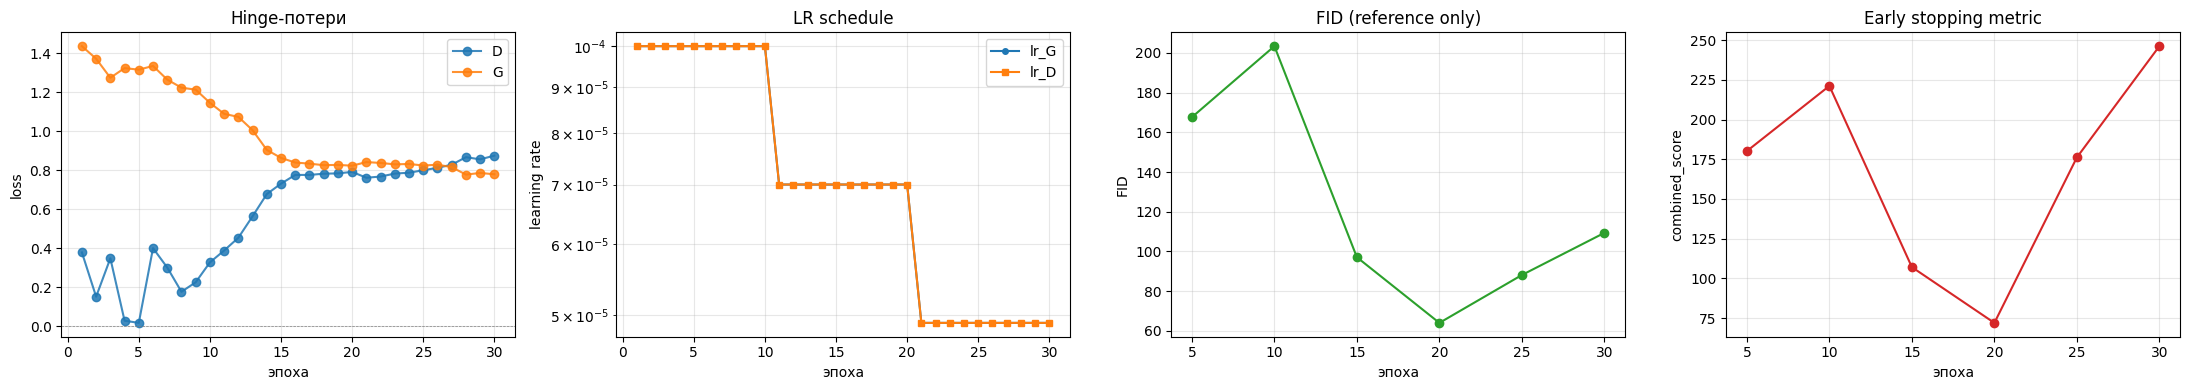

In [13]:
if RUN_MASK_GAN_BASELINE and history.get("epoch"):
    def plot_history(history):
        """Строит график потерь, LR, FID и combined_score по eval-точкам."""
        ep = np.array(history["epoch"])
    
        fig, ax = plt.subplots(1, 4, figsize=(22, 4))
    
        ax[0].plot(ep, history["loss_d"], "o-", label="D", alpha=0.85)
        ax[0].plot(ep, history["loss_g"], "o-", label="G", alpha=0.85)
        ax[0].axhline(0, color="gray", lw=0.5, ls="--")
        ax[0].set_xlabel("эпоха"); ax[0].set_ylabel("loss")
        ax[0].set_title("Hinge-потери")
        ax[0].legend(); ax[0].grid(alpha=0.3)
    
        ax[1].plot(ep, history["lr_g"], "o-", label="lr_G", ms=4)
        ax[1].plot(ep, history["lr_d"], "s-", label="lr_D", ms=4)
        ax[1].set_xlabel("эпоха"); ax[1].set_ylabel("learning rate"); ax[1].set_yscale("log")
        ax[1].set_title("LR schedule"); ax[1].legend(); ax[1].grid(alpha=0.3, which="both")
    
        fid_points = [(e, f) for e, f in zip(history["epoch"], history["fid"]) if f is not None]
        if fid_points:
            x, y = zip(*fid_points)
            ax[2].plot(x, y, "o-", color="tab:green")
        ax[2].set_xlabel("эпоха"); ax[2].set_ylabel("FID")
        ax[2].set_title("FID (reference only)")
        ax[2].grid(alpha=0.3)
    
        score_points = [(e, s) for e, s in zip(history["epoch"], history["combined_score"]) if s is not None]
        if score_points:
            x, y = zip(*score_points)
            ax[3].plot(x, y, "o-", color="tab:red")
        ax[3].set_xlabel("эпоха"); ax[3].set_ylabel("combined_score")
        ax[3].set_title("Early stopping metric")
        ax[3].grid(alpha=0.3)
    
        plt.tight_layout()
        plt.savefig(WORK / "losses.png", dpi=120, bbox_inches="tight")
        plt.show()
    
    
    plot_history(history)
    
else:
    print("Mask-GAN history plot skipped.")


## Stage 6 — Генерация картинок

Генерацию тоже выносим в **отдельную функцию** `generate_images`. Используем `G_ema`
(сглаженный генератор) — он даёт более стабильные результаты, чем «сырой» `G`.

Генерируем 1000 картинок: они пойдут в расчёт FID/IS (Stage 7) и в bundle.
Дополнительно рисуем превью-сетку 8×4 (первые 32 из них).


/tmp/ipykernel_58/2330838146.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(raw_mask_imgs[i, 0], "L").save(GEN_DIR / f"mask_raw_{i:05d}.png")
/tmp/ipykernel_58/2330838146.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(post_mask_imgs[i, 0], "L").save(GEN_DIR / f"mask_postprocessed_{i:05d}.png")
/tmp/ipykernel_58/2330838146.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(raw_vis_imgs[i].transpose(1, 2, 0), "RGB").save(GEN_DIR / f"court_raw_{i:05d}.png")
/tmp/ipykernel_58/2330838146.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(post_vis_imgs[i].transpose(1, 2, 0), "RGB").save(GEN_DIR / f"court_postprocessed_{i:05d}.png")


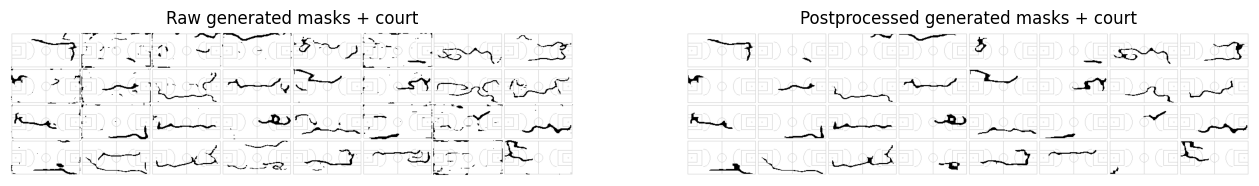

In [14]:
if RUN_MASK_GAN_BASELINE and G_ema is not None:
    N_SAMPLES = 100 if SMOKE_TEST else 1000
    fakes = generate_images(G_ema, N_SAMPLES, Z_DIM)
    fakes_postprocessed = postprocess_generated_masks(fakes)
    
    raw_mask_imgs = ((1.0 - binarize_fake_masks(fakes).float()) * 255).byte().numpy()
    post_mask_imgs = (mask_to_01(fakes_postprocessed) * 255).byte().numpy()
    raw_vis_imgs = (overlay_masks_on_court(fakes, kind="fake_raw") * 255).byte().numpy()
    post_vis_imgs = (overlay_masks_on_court(fakes, kind="fake_postprocessed") * 255).byte().numpy()
    
    for i in range(N_SAMPLES):
        Image.fromarray(raw_mask_imgs[i, 0], "L").save(GEN_DIR / f"mask_raw_{i:05d}.png")
        Image.fromarray(post_mask_imgs[i, 0], "L").save(GEN_DIR / f"mask_postprocessed_{i:05d}.png")
        Image.fromarray(raw_vis_imgs[i].transpose(1, 2, 0), "RGB").save(GEN_DIR / f"court_raw_{i:05d}.png")
        Image.fromarray(post_vis_imgs[i].transpose(1, 2, 0), "RGB").save(GEN_DIR / f"court_postprocessed_{i:05d}.png")
    
    grid_raw = save_overlay_grid(fakes[:32], WORK / "generated_examples_raw.png", nrow=8, kind="fake_raw")
    grid_post = save_overlay_grid(fakes[:32], WORK / "generated_examples_postprocessed.png", nrow=8, kind="fake_postprocessed")
    save_image(1.0 - binarize_fake_masks(fakes[:32]).float(), WORK / "grid_8x4_masks_raw.png", nrow=8, padding=2, pad_value=1.0)
    save_image(mask_to_01(fakes_postprocessed[:32]), WORK / "grid_8x4_masks_postprocessed.png", nrow=8, padding=2, pad_value=1.0)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(grid_raw.permute(1, 2, 0).numpy()); axes[0].axis("off"); axes[0].set_title("Raw generated masks + court")
    axes[1].imshow(grid_post.permute(1, 2, 0).numpy()); axes[1].axis("off"); axes[1].set_title("Postprocessed generated masks + court")
    plt.show()
    
else:
    print("Mask-GAN generation skipped.")
    fakes = None
    fakes_postprocessed = None


## Stage 7 — Финальные метрики

FID/Inception считаются на mask-тензорах; для Inception 1 канал временно повторяется до 3.

Line metrics считаются отдельно по real/fake mask без корта и сохраняются в `line_metrics.csv` и `line_metrics.json`.


In [15]:
if RUN_MASK_GAN_BASELINE and G_ema is not None:
    metrics, eval_fakes_raw, eval_fakes_postprocessed, eval_reals = evaluate_generation(G_ema, test_files, n=EVAL_N, batch=64)
    metrics.update({"split": "by_game_id_seed42", "loss": "hinge", "image_channels": IMG_C, "generator_width": FG, "discriminator_width": FD, "best_epoch": best_info["best_epoch"], "best_fid": best_info["best_fid"], "best_combined_score": best_info["best_combined_score"]})
    (WORK / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    print(json.dumps({k: v for k, v in metrics.items() if k != "line_metrics"}, indent=2))
    line_summary = pd.DataFrame(metrics["line_metrics"])
    display(line_summary)
    
else:
    print("Mask-GAN metrics skipped.")
    metrics = None
    line_summary = None
    eval_fakes_raw = None
    eval_fakes_postprocessed = None
    eval_reals = None


{
  "inception_score_mean": 2.044734477996826,
  "inception_score_std": 0.1062842532992363,
  "fid": 65.67872743448797,
  "combined_score": 73.50123720011297,
  "combined_score_fake_split": "fake_postprocessed",
  "real_black_pixel_ratio": 0.047460205078125,
  "fake_black_pixel_ratio": 0.031815185546875,
  "real_connected_components_count": 1.0,
  "fake_connected_components_count": 1.0,
  "fake_fraction_of_broken_trajectories": 0.0,
  "n_real": 500,
  "n_fake": 500,
  "real_black_ratio_target": 0.04840087890625,
  "split": "by_game_id_seed42",
  "loss": "hinge",
  "image_channels": 1,
  "generator_width": 64,
  "discriminator_width": 64,
  "best_epoch": 20,
  "best_fid": 64.04294859011506,
  "best_combined_score": 71.95847593386506
}


,split,metric,mean,std
0,real,black_pixel_ratio,0.047460,0.019792
1,real,connected_components_count,1.000000,0.000000
2,real,bbox_width,88.934000,29.387712
3,real,bbox_height,32.462000,13.691477
4,real,approximate_line_length,145.460000,63.333817
5,real,fraction_of_broken_trajectories,0.000000,0.000000
6,fake_raw,black_pixel_ratio,0.048456,0.000641
7,fake_raw,connected_components_count,10.040000,8.420831
8,fake_raw,bbox_width,113.400000,16.220727
9,fake_raw,bbox_height,49.442000,14.971394


## Stage 8 — Визуальное сравнение real vs generated

Слева и справа показываем уже не сырой вход модели, а удобную для человека визуализацию:

- белый фон;
- серый court template;
- чёрная траектория из real/fake mask.


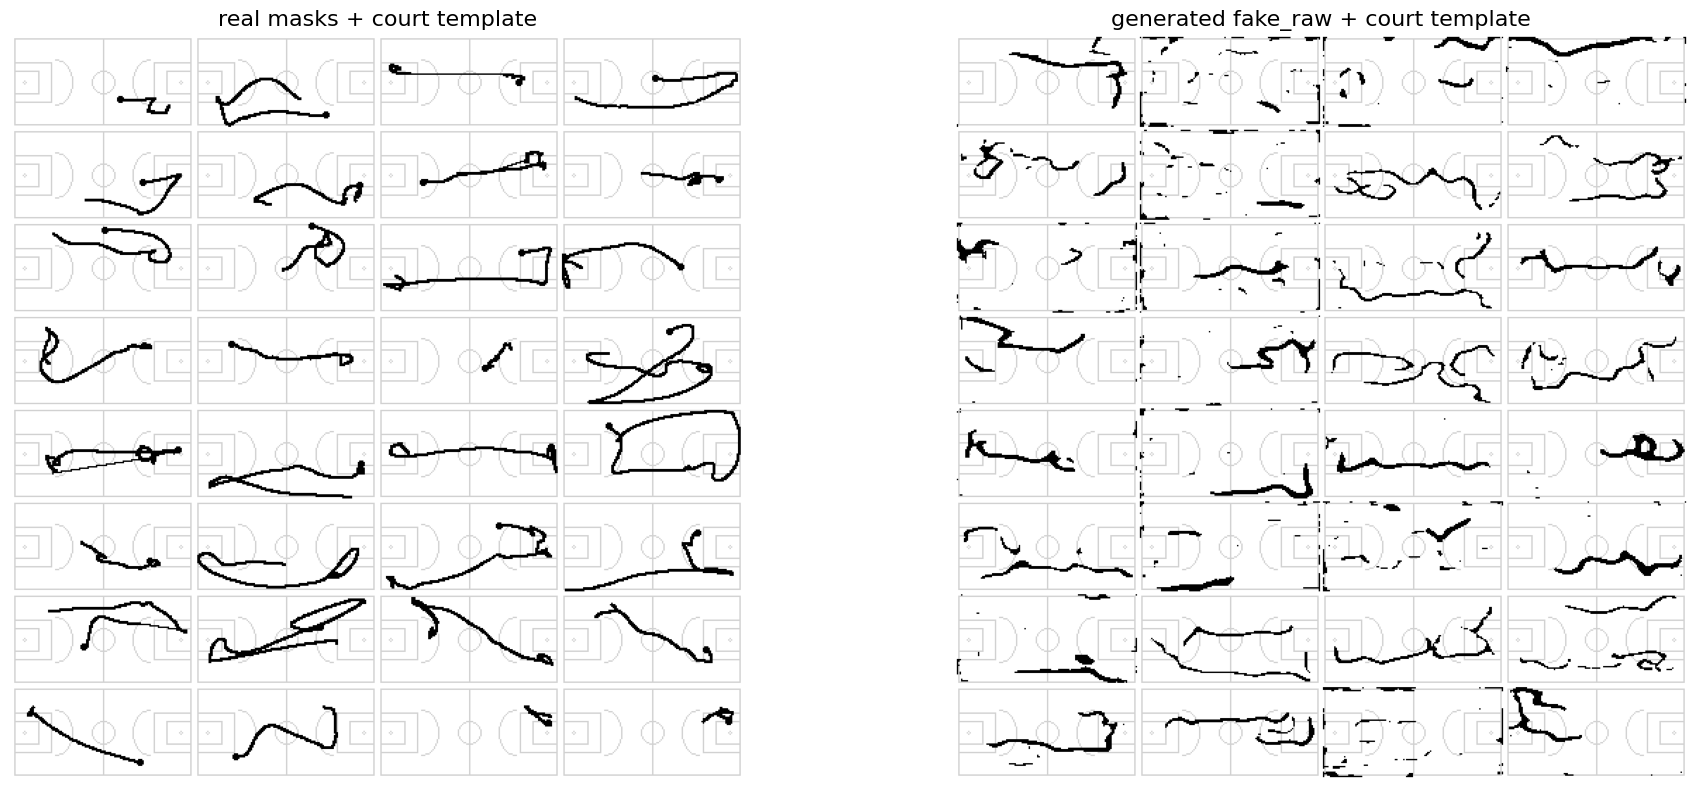

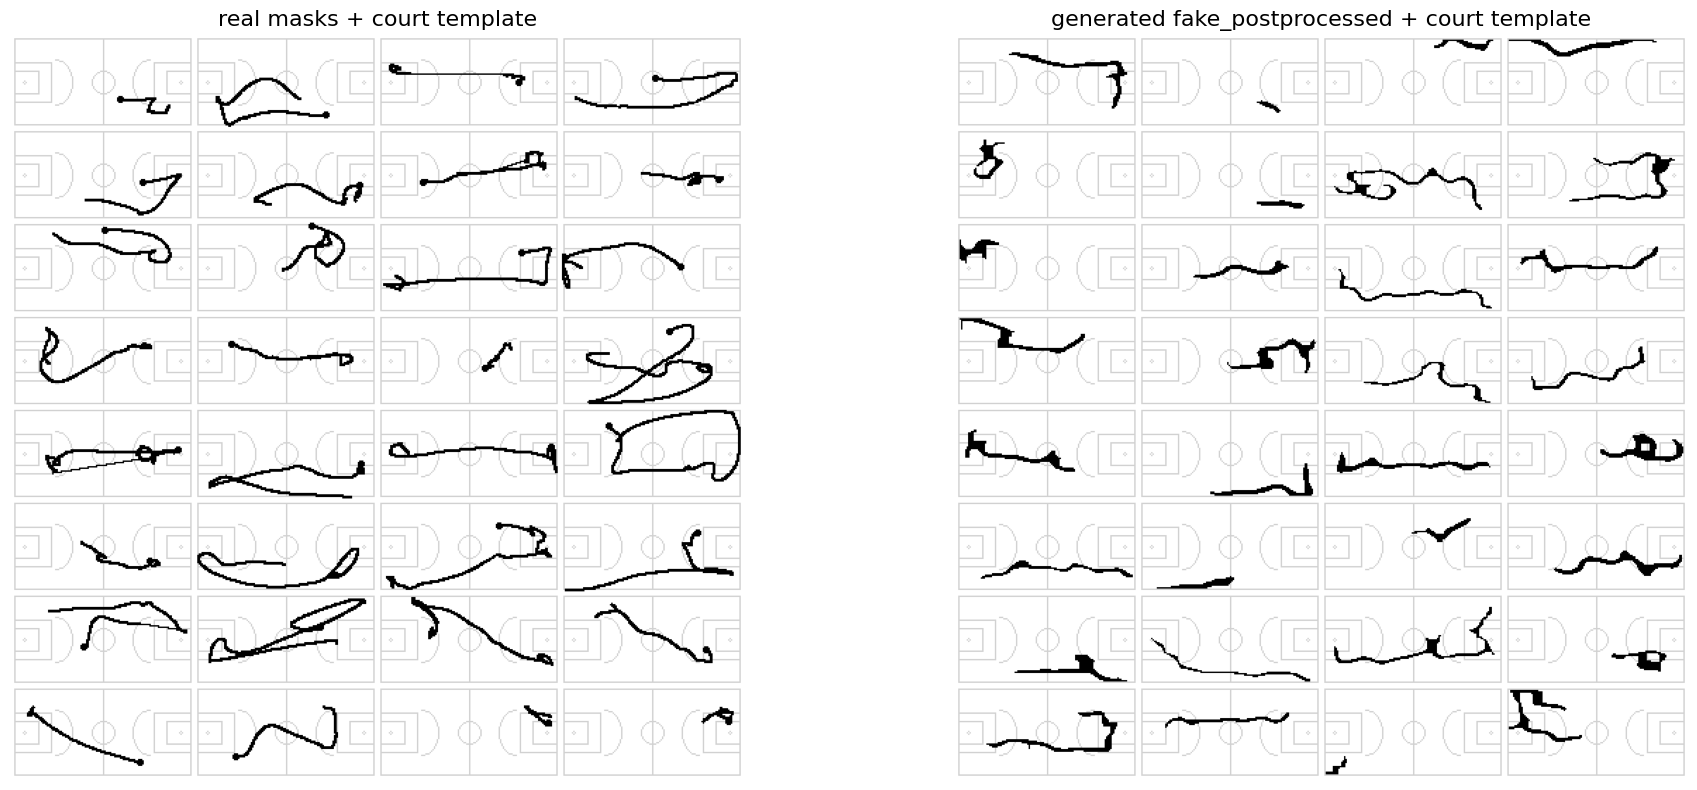

In [16]:
if RUN_MASK_GAN_BASELINE and fakes is not None:
    def show_comparison(test_files, fakes, k=32, *, kind="fake_postprocessed", filename="compare_postprocessed.png"):
        random.seed(SEED)
        sample = random.sample(test_files, min(k, len(test_files)))
        ds = TrajectoryDataset(sample)
        real_batch = torch.stack([ds[i] for i in range(len(sample))])
        fake_batch = fakes[:len(sample)]
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, batch, title, vis_kind in zip(axes, [real_batch, fake_batch], ["real masks + court template", f"generated {kind} + court template"], ["real", kind]):
            vis = overlay_masks_on_court(batch, kind=vis_kind)
            arr = make_grid(vis, nrow=4, padding=2, pad_value=1.0).clamp(0, 1)
            ax.imshow(arr.numpy().transpose(1, 2, 0))
            ax.set_title(title, fontsize=16); ax.axis("off")
        fig.tight_layout()
        fig.savefig(WORK / filename, dpi=120, bbox_inches="tight")
        plt.show()
    
    
    show_comparison(test_files, fakes, k=32, kind="fake_raw", filename="compare_raw.png")
    show_comparison(test_files, fakes, k=32, kind="fake_postprocessed", filename="compare_postprocessed.png")
    
else:
    print("Mask-GAN comparison images skipped.")


## Stage 9 — Summary и сборка bundle для скачивания

В конце создаётся архив результатов `training_bundle_mask_gan.zip`. Его можно скачать прямо из Kaggle по ссылке `FileLink` или из панели файлов.


In [17]:
print("Mask-GAN baseline section complete.")
if RUN_MASK_GAN_BASELINE and line_summary is not None:
    print("Mask-GAN line metrics:")
    display(line_summary)
else:
    print("Mask-GAN baseline was not run in this execution.")


Mask-GAN baseline section complete.
Mask-GAN line metrics:


,split,metric,mean,std
0,real,black_pixel_ratio,0.047460,0.019792
1,real,connected_components_count,1.000000,0.000000
2,real,bbox_width,88.934000,29.387712
3,real,bbox_height,32.462000,13.691477
4,real,approximate_line_length,145.460000,63.333817
5,real,fraction_of_broken_trajectories,0.000000,0.000000
6,fake_raw,black_pixel_ratio,0.048456,0.000641
7,fake_raw,connected_components_count,10.040000,8.420831
8,fake_raw,bbox_width,113.400000,16.220727
9,fake_raw,bbox_height,49.442000,14.971394


## Stage 10 — Полная очистка `/colab/working`

Запускать **только вручную**, после скачивания bundle. Удаляет вообще всё, включая
кэш сплита и копию train-данных. Нужно, только если меняешь состав данных
(`FULL_TRAIN_IMAGES`, `FULL_TEST_IMAGES`, `TEST_FRACTION`, источник) — тогда Stage 1 пересоберёт всё заново.



In [18]:
RUN_FULL_CLEANUP = False                                   ### включать только вручную после скачивания bundle

if RUN_FULL_CLEANUP:
    removed = []
    for entry in WORK.iterdir():
        if entry.is_dir():
            shutil.rmtree(entry)
        else:
            entry.unlink()
        removed.append(entry.name)
    print("Удалено:", sorted(removed) or "(уже пусто)")
    print("/kaggle/working:", sorted(p.name for p in WORK.iterdir()) or "(пусто)")
else:
    print("Cleanup пропущен. Поставь RUN_FULL_CLEANUP = True только после скачивания результатов.")


Cleanup пропущен. Поставь RUN_FULL_CLEANUP = True только после скачивания результатов.


## Stage 11 — Coordinate Trajectory Dataset


In [19]:
### ====================== Coordinate trajectory utilities ======================
from torch.utils.data import TensorDataset

COORD_DIR = WORK / "coordinate_models"
COORD_DIR.mkdir(parents=True, exist_ok=True)


def mask_to_binary(mask):
    """Tensor [1,H,W] или [H,W] -> numpy bool, True = trajectory."""
    if isinstance(mask, torch.Tensor):
        x = mask.detach().cpu().float()
        if x.ndim == 3:
            x = x[0]
        if x.min() < 0:
            x = (x + 1.0) / 2.0
        return (x.numpy() < 0.5).astype(bool)
    arr = np.asarray(mask)
    if arr.ndim == 3:
        arr = arr[0]
    return (arr < 0.5).astype(bool)


def _largest_component(binary):
    from scipy import ndimage
    lab, n = ndimage.label(binary, structure=np.ones((3, 3), dtype=np.uint8))
    if n == 0:
        return None
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    return lab == int(counts.argmax())


def _skeletonize_binary(binary):
    try:
        from skimage.morphology import skeletonize
        return skeletonize(binary).astype(bool)
    except Exception:
        return binary.astype(bool)


def _trace_skeleton_path(skel):
    coords = np.argwhere(skel)
    if len(coords) < 2:
        return None
    pix = {tuple(p) for p in coords}
    def neigh(p):
        y, x = p
        out = []
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                q = (y + dy, x + dx)
                if q in pix:
                    out.append(q)
        return out
    degrees = {p: len(neigh(p)) for p in pix}
    endpoints = [p for p, d in degrees.items() if d == 1]
    start = min(endpoints, key=lambda p: p[1]) if endpoints else min(pix, key=lambda p: p[1])
    path = [start]
    visited = {start}
    cur = start
    while True:
        candidates = [q for q in neigh(cur) if q not in visited]
        if not candidates:
            break
        candidates.sort(key=lambda q: (q[1] - cur[1]) ** 2 + (q[0] - cur[0]) ** 2)
        cur = candidates[0]
        visited.add(cur)
        path.append(cur)
        if len(path) >= len(pix):
            break
    if len(path) < 2:
        return None
    arr = np.array(path, dtype=np.float32)
    return arr[:, [1, 0]]  # x,y pixels


def extract_ordered_trajectory_points(binary_mask):
    comp = _largest_component(binary_mask)
    if comp is None or comp.sum() < 2:
        return None
    skel = _skeletonize_binary(comp)
    pts = _trace_skeleton_path(skel)
    if pts is None or len(pts) < 2:
        coords = np.argwhere(comp)
        if len(coords) < 2:
            return None
        pts = coords[:, [1, 0]].astype(np.float32)
        pts = pts[np.argsort(pts[:, 0])]
    pts[:, 0] = pts[:, 0] / max(1, binary_mask.shape[1] - 1)
    pts[:, 1] = pts[:, 1] / max(1, binary_mask.shape[0] - 1)
    pts = np.clip(pts, 0.0, 1.0)
    return pts.astype(np.float32)


def resample_trajectory(points, num_points=COORD_NUM_POINTS):
    points = np.asarray(points, dtype=np.float32)
    if len(points) < 2:
        return None
    diffs = np.diff(points, axis=0)
    seg = np.sqrt((diffs ** 2).sum(axis=1))
    dist = np.concatenate([[0.0], np.cumsum(seg)])
    total = dist[-1]
    if total <= 1e-6:
        return None
    target = np.linspace(0.0, total, num_points)
    x = np.interp(target, dist, points[:, 0])
    y = np.interp(target, dist, points[:, 1])
    return np.stack([x, y], axis=1).clip(0.0, 1.0).astype(np.float32)


def build_coordinate_dataset(files, max_samples, cache_name, num_points=COORD_NUM_POINTS):
    cache_path = WORK / cache_name
    meta_path = WORK / cache_name.replace('.npy', '_meta.json')
    if cache_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text())
        if meta.get('num_points') == num_points and meta.get('max_samples') == max_samples:
            arr = np.load(cache_path)
            print(f"Loaded coordinate cache {cache_path}: {arr.shape}")
            return arr
    subset = list(files)[:max_samples]
    ds = TrajectoryDataset(subset)
    coords = []
    skipped = 0
    for i in tqdm(range(len(ds)), desc=f"build {cache_name}"):
        binary = mask_to_binary(ds[i])
        pts = extract_ordered_trajectory_points(binary)
        if pts is None:
            skipped += 1
            continue
        res = resample_trajectory(pts, num_points=num_points)
        if res is None:
            skipped += 1
            continue
        coords.append(res)
    arr = np.asarray(coords, dtype=np.float32)
    np.save(cache_path, arr)
    meta_path.write_text(json.dumps({"num_points": num_points, "max_samples": max_samples, "processed": len(subset), "valid": int(len(arr)), "skipped": int(skipped)}, indent=2))
    print("processed:", len(subset), "valid:", len(arr), "skipped:", skipped, "shape:", arr.shape)
    return arr


def render_trajectory_points(points, h=64, w=128, line_width=2, draw_endpoint=True):
    pts = np.asarray(points, dtype=np.float32).clip(0.0, 1.0)
    img = Image.new("L", (w, h), 255)
    d = ImageDraw.Draw(img)
    xy = [(float(x) * (w - 1), float(y) * (h - 1)) for x, y in pts]
    if len(xy) >= 2:
        d.line(xy, fill=0, width=line_width, joint="curve")
    if draw_endpoint and len(xy):
        x, y = xy[-1]
        r = 2
        d.ellipse([x-r, y-r, x+r, y+r], fill=0)
    arr = transforms.ToTensor()(img)
    return arr * 2.0 - 1.0


def render_trajectory_batch(points_batch, h=64, w=128, line_width=2):
    return torch.stack([render_trajectory_points(p, h=h, w=w, line_width=line_width) for p in points_batch])


def coordinate_metrics(points_batch):
    pts = np.asarray(points_batch, dtype=np.float32)
    diffs = np.diff(pts, axis=1)
    seg = np.sqrt((diffs ** 2).sum(axis=2))
    path_len = seg.sum(axis=1)
    disp = np.sqrt(((pts[:, -1] - pts[:, 0]) ** 2).sum(axis=1))
    bbox_w = pts[:, :, 0].max(axis=1) - pts[:, :, 0].min(axis=1)
    bbox_h = pts[:, :, 1].max(axis=1) - pts[:, :, 1].min(axis=1)
    oob = ((pts < 0) | (pts > 1)).any(axis=2).mean(axis=1)
    return {
        "mean_start_x": float(pts[:, 0, 0].mean()), "mean_start_y": float(pts[:, 0, 1].mean()),
        "mean_end_x": float(pts[:, -1, 0].mean()), "mean_end_y": float(pts[:, -1, 1].mean()),
        "path_length_mean": float(path_len.mean()), "path_length_std": float(path_len.std()),
        "displacement_mean": float(disp.mean()), "displacement_std": float(disp.std()),
        "bbox_width_mean": float(bbox_w.mean()), "bbox_height_mean": float(bbox_h.mean()),
        "smoothness_mean": float(seg.mean()), "percent_out_of_bounds": float(oob.mean()),
    }


def summarize_rendered_model(name, masks):
    df = line_metrics_per_image(masks, kind="real")
    rows = []
    for col in ["black_pixel_ratio", "connected_components_count", "bbox_width", "bbox_height", "approximate_line_length", "broken_trajectory"]:
        metric = "fraction_of_broken_trajectories" if col == "broken_trajectory" else col
        rows.append({"model": name, "metric": metric, "mean": float(df[col].mean()), "std": float(df[col].std(ddof=0))})
    return rows


In [20]:
### ====================== Build coordinate datasets ======================
if SMOKE_TEST:
    COORD_TRAIN_SAMPLES = min(512, len(train_files))
    COORD_TEST_SAMPLES = min(128, len(test_files))
    EPOCHS_COORD_GAN = 2
    EPOCHS_COORD_VAE = 2
    COORD_BATCH = 64
elif FAST_DEBUG:
    COORD_TRAIN_SAMPLES = min(50_000, len(train_files))
    COORD_TEST_SAMPLES = min(1_000, len(test_files))
    EPOCHS_COORD_GAN = 50
    EPOCHS_COORD_VAE = 50
    COORD_BATCH = COORD_BATCH_SIZE
else:
    COORD_TRAIN_SAMPLES = min(200_000, len(train_files))
    COORD_TEST_SAMPLES = min(5_000, len(test_files))
    EPOCHS_COORD_GAN = 100
    EPOCHS_COORD_VAE = 100
    COORD_BATCH = COORD_BATCH_SIZE

print("Coordinate config:", COORD_TRAIN_SAMPLES, COORD_TEST_SAMPLES, EPOCHS_COORD_GAN, EPOCHS_COORD_VAE, COORD_BATCH)
X_train_coord = build_coordinate_dataset(train_files, COORD_TRAIN_SAMPLES, "coord_cache_train.npy")
X_test_coord = build_coordinate_dataset(test_files, COORD_TEST_SAMPLES, "coord_cache_test.npy")
print("X_train_coord:", X_train_coord.shape, "X_test_coord:", X_test_coord.shape)

coord_train_tensor = torch.tensor(X_train_coord.reshape(len(X_train_coord), -1), dtype=torch.float32)
coord_test_tensor = torch.tensor(X_test_coord.reshape(len(X_test_coord), -1), dtype=torch.float32)
coord_train_loader = DataLoader(TensorDataset(coord_train_tensor), batch_size=COORD_BATCH, shuffle=True, drop_last=True)
coord_val_loader = DataLoader(TensorDataset(coord_test_tensor), batch_size=COORD_BATCH, shuffle=False)


Coordinate config: 50000 1000 50 50 256


build coord_cache_train.npy:   0%|          | 0/50000 [00:00<?, ?it/s]

processed: 50000 valid: 50000 skipped: 0 shape: (50000, 50, 2)


build coord_cache_test.npy:   0%|          | 0/1000 [00:00<?, ?it/s]

processed: 1000 valid: 1000 skipped: 0 shape: (1000, 50, 2)
X_train_coord: (50000, 50, 2) X_test_coord: (1000, 50, 2)


## Stage 12 — Coordinate-VAE


In [21]:
### ====================== Coordinate-VAE ======================
class CoordinateVAE(nn.Module):
    def __init__(self, input_dim=COORD_NUM_POINTS*2, latent_dim=COORD_LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU())
        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, input_dim), nn.Sigmoid())
    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std
    def decode(self, z):
        return self.decoder(z).view(-1, COORD_NUM_POINTS, 2)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        out = self.decoder(z)
        return out, mu, logvar


def train_coordinate_vae():
    model = CoordinateVAE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=COORD_LR_VAE)
    best_val = float('inf')
    logs = []
    for epoch in range(1, EPOCHS_COORD_VAE + 1):
        model.train(); total = recon_total = kl_total = 0.0
        for (x,) in tqdm(coord_train_loader, desc=f"coord VAE {epoch:03d}", leave=False):
            x = x.to(device)
            opt.zero_grad(set_to_none=True)
            out, mu, logvar = model(x)
            out_flat = out.view(x.size(0), -1)
            recon = F.mse_loss(out_flat, x)
            kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon + COORD_VAE_BETA * kl
            loss.backward(); opt.step()
            total += loss.item(); recon_total += recon.item(); kl_total += kl.item()
        model.eval(); vals = []
        with torch.no_grad():
            for (x,) in coord_val_loader:
                x = x.to(device)
                out, _, _ = model(x)
                vals.append(F.mse_loss(out.view(x.size(0), -1), x).item())
        val = float(np.mean(vals))
        row = {"epoch": epoch, "train_loss": total/max(1,len(coord_train_loader)), "val_loss": val, "recon_loss": recon_total/max(1,len(coord_train_loader)), "kl": kl_total/max(1,len(coord_train_loader))}
        logs.append(row)
        print("VAE", row)
        if val < best_val:
            best_val = val
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": val}, WORK / "best_coord_vae.pt")
    pd.DataFrame(logs).to_csv(WORK / "coord_vae_log.csv", index=False)
    ckpt = torch.load(WORK / "best_coord_vae.pt", map_location=device)
    model.load_state_dict(ckpt["model"])
    return model.eval(), logs

if RUN_COORD_VAE:
    coord_vae, coord_vae_logs = train_coordinate_vae()
else:
    coord_vae = None


coord VAE 001:   0%|          | 0/195 [00:00<?, ?it/s]

VAE {'epoch': 1, 'train_loss': 0.01880580086547595, 'val_loss': 0.005899040028452873, 'recon_loss': 0.017581559870487606, 'kl': 1.2242409387507882}


coord VAE 002:   0%|          | 0/195 [00:00<?, ?it/s]

VAE {'epoch': 2, 'train_loss': 0.005996090531922304, 'val_loss': 0.0023722589830867946, 'recon_loss': 0.004497781830529372, 'kl': 1.4983086372033143}


coord VAE 003:   0%|          | 0/195 [00:00<?, ?it/s]

...

VAE {'epoch': 48, 'train_loss': 0.0011649256112436072, 'val_loss': 0.0005219965241849422, 'recon_loss': 0.0005254015339932476, 'kl': 0.6395240429120186}


coord VAE 049:   0%|          | 0/195 [00:00<?, ?it/s]

VAE {'epoch': 49, 'train_loss': 0.0011700232805779728, 'val_loss': 0.0005022747354814783, 'recon_loss': 0.0005315072497185798, 'kl': 0.6385160002952966}


coord VAE 050:   0%|          | 0/195 [00:00<?, ?it/s]

VAE {'epoch': 50, 'train_loss': 0.0011668187440731204, 'val_loss': 0.0005408089491538703, 'recon_loss': 0.0005280735739805281, 'kl': 0.6387451404180282}


## Stage 13 — Coordinate-GAN


In [22]:
### ====================== Coordinate-GAN ======================
class CoordGenerator(nn.Module):
    def __init__(self, z_dim=COORD_Z_DIM, output_dim=COORD_NUM_POINTS*2):
        super().__init__()
        self.z_dim = z_dim
        self.net = nn.Sequential(nn.Linear(z_dim, 128), nn.LeakyReLU(0.2), nn.Linear(128, 256), nn.LeakyReLU(0.2), nn.Linear(256, output_dim), nn.Sigmoid())
    def forward(self, z):
        return self.net(z).view(-1, COORD_NUM_POINTS, 2)

class CoordDiscriminator(nn.Module):
    def __init__(self, input_dim=COORD_NUM_POINTS*2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 256), nn.LeakyReLU(0.2), nn.Dropout(0.2), nn.Linear(256, 128), nn.LeakyReLU(0.2), nn.Dropout(0.2), nn.Linear(128, 1))
    def forward(self, x):
        return self.net(x.view(x.size(0), -1)).squeeze(1)

class SimpleEMA:
    def __init__(self, model, decay=0.995):
        self.decay = decay
        self.shadow = deepcopy(model).eval()
        for p in self.shadow.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.mul_(self.decay).add_(m, alpha=1-self.decay)


def coord_validation_score(points):
    masks = render_trajectory_batch(points)
    rows = summarize_rendered_model("coord", masks)
    df = pd.DataFrame(rows)
    broken = float(df[(df.metric=="fraction_of_broken_trajectories")]["mean"].iloc[0])
    cc = float(df[(df.metric=="connected_components_count")]["mean"].iloc[0])
    cm = coordinate_metrics(points)
    real_cm = coordinate_metrics(X_test_coord[:min(len(X_test_coord), len(points))])
    return broken * 100 + abs(cc - 1) * 5 + abs(cm["path_length_mean"] - real_cm["path_length_mean"]) * 50


def train_coordinate_gan():
    Gc = CoordGenerator().to(device)
    Dc = CoordDiscriminator().to(device)
    opt_g = torch.optim.Adam(Gc.parameters(), lr=COORD_LR_G, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(Dc.parameters(), lr=COORD_LR_D, betas=(0.5, 0.999))
    ema = SimpleEMA(Gc)
    best_score = float('inf')
    logs = []
    fixed_z = torch.randn(32, COORD_Z_DIM, device=device)
    for epoch in range(1, EPOCHS_COORD_GAN + 1):
        Gc.train(); Dc.train(); d_sum = g_sum = steps = 0
        for (real,) in tqdm(coord_train_loader, desc=f"coord GAN {epoch:03d}", leave=False):
            real = real.to(device).view(real.size(0), COORD_NUM_POINTS, 2)
            bs = real.size(0)
            opt_d.zero_grad(set_to_none=True)
            z = torch.randn(bs, COORD_Z_DIM, device=device)
            fake = Gc(z).detach()
            loss_d = F.relu(1.0 - Dc(real)).mean() + F.relu(1.0 + Dc(fake)).mean()
            loss_d.backward(); torch.nn.utils.clip_grad_norm_(Dc.parameters(), 1.0); opt_d.step()
            opt_g.zero_grad(set_to_none=True)
            z = torch.randn(bs, COORD_Z_DIM, device=device)
            loss_g = -Dc(Gc(z)).mean()
            loss_g.backward(); torch.nn.utils.clip_grad_norm_(Gc.parameters(), 1.0); opt_g.step(); ema.update(Gc)
            d_sum += loss_d.item(); g_sum += loss_g.item(); steps += 1
        score = None
        if epoch % 5 == 0 or epoch == EPOCHS_COORD_GAN:
            with torch.no_grad():
                preview_pts = ema.shadow(fixed_z).cpu().numpy()
            preview_masks = render_trajectory_batch(preview_pts)
            save_overlay_grid(preview_masks, SAMPLES_DIR / f"coord_gan_epoch_{epoch:04d}.png", nrow=8, kind="real")
            score = coord_validation_score(preview_pts)
            if score < best_score:
                best_score = score
                torch.save({"G": Gc.state_dict(), "G_ema": ema.shadow.state_dict(), "D": Dc.state_dict(), "epoch": epoch, "score": score}, WORK / "best_coord_gan.pt")
        row = {"epoch": epoch, "loss_d": d_sum/max(1,steps), "loss_g": g_sum/max(1,steps), "val_score": score}
        logs.append(row); print("CoordGAN", row)
    pd.DataFrame(logs).to_csv(WORK / "coord_gan_log.csv", index=False)
    ckpt = torch.load(WORK / "best_coord_gan.pt", map_location=device)
    Gc.load_state_dict(ckpt["G_ema"])
    return Gc.eval(), logs

if RUN_COORD_GAN:
    coord_gan, coord_gan_logs = train_coordinate_gan()
else:
    coord_gan = None


coord GAN 001:   0%|          | 0/195 [00:00<?, ?it/s]

CoordGAN {'epoch': 1, 'loss_d': 1.5657517274220785, 'loss_g': 0.3038417794956611, 'val_score': None}


coord GAN 002:   0%|          | 0/195 [00:00<?, ?it/s]

CoordGAN {'epoch': 2, 'loss_d': 1.744512383143107, 'loss_g': 0.07964295944294486, 'val_score': None}


coord GAN 003:   0%|          | 0/195 [00:00<?, ?it/s]

...

CoordGAN {'epoch': 48, 'loss_d': 1.9074436059364905, 'loss_g': 0.11809289841793287, 'val_score': None}


coord GAN 049:   0%|          | 0/195 [00:00<?, ?it/s]

CoordGAN {'epoch': 49, 'loss_d': 1.9104639560748369, 'loss_g': 0.12827511381787748, 'val_score': None}


coord GAN 050:   0%|          | 0/195 [00:00<?, ?it/s]

CoordGAN {'epoch': 50, 'loss_d': 1.9209721693625816, 'loss_g': 0.12273710889455218, 'val_score': 60.207951068878174}


## Stage 14 — Model Comparison


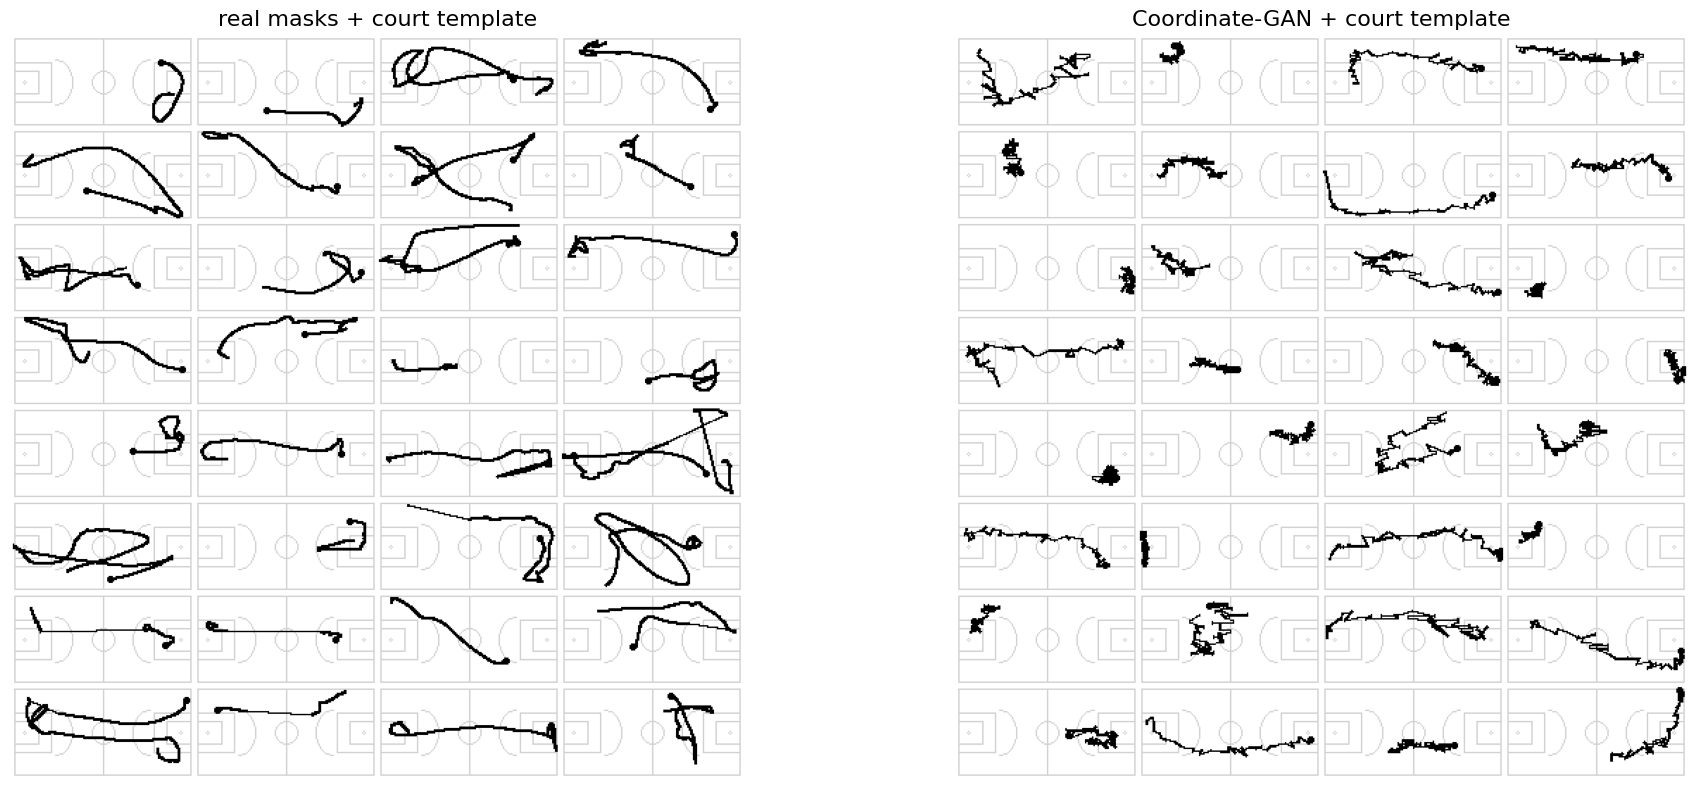

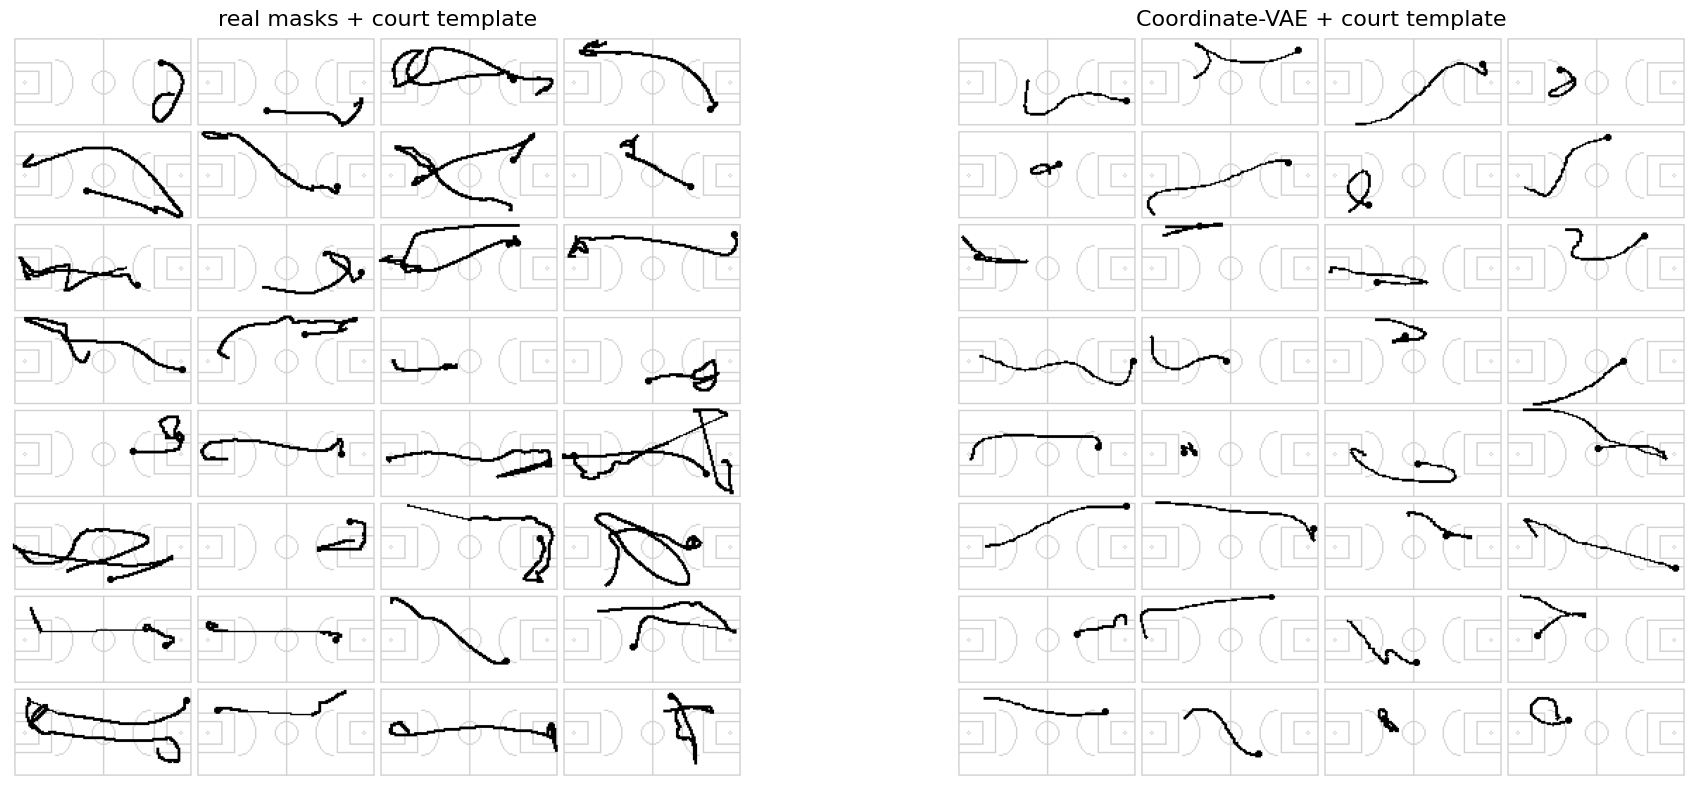

,model,metric,mean,std
0,Mask-GAN raw,black_pixel_ratio,0.048456,NaN
1,Mask-GAN raw,connected_components_count,10.040000,NaN
2,Mask-GAN raw,fraction_of_broken_trajectories,0.960000,NaN
3,Mask-GAN raw,approximate_line_length,163.486000,NaN
4,Mask-GAN raw,bbox_width,113.400000,NaN
5,Mask-GAN raw,bbox_height,49.442000,NaN
6,Mask-GAN postprocessed,black_pixel_ratio,0.031815,NaN
7,Mask-GAN postprocessed,connected_components_count,1.000000,NaN
8,Mask-GAN postprocessed,fraction_of_broken_trajectories,0.000000,NaN
9,Mask-GAN postprocessed,approximate_line_length,84.444000,NaN


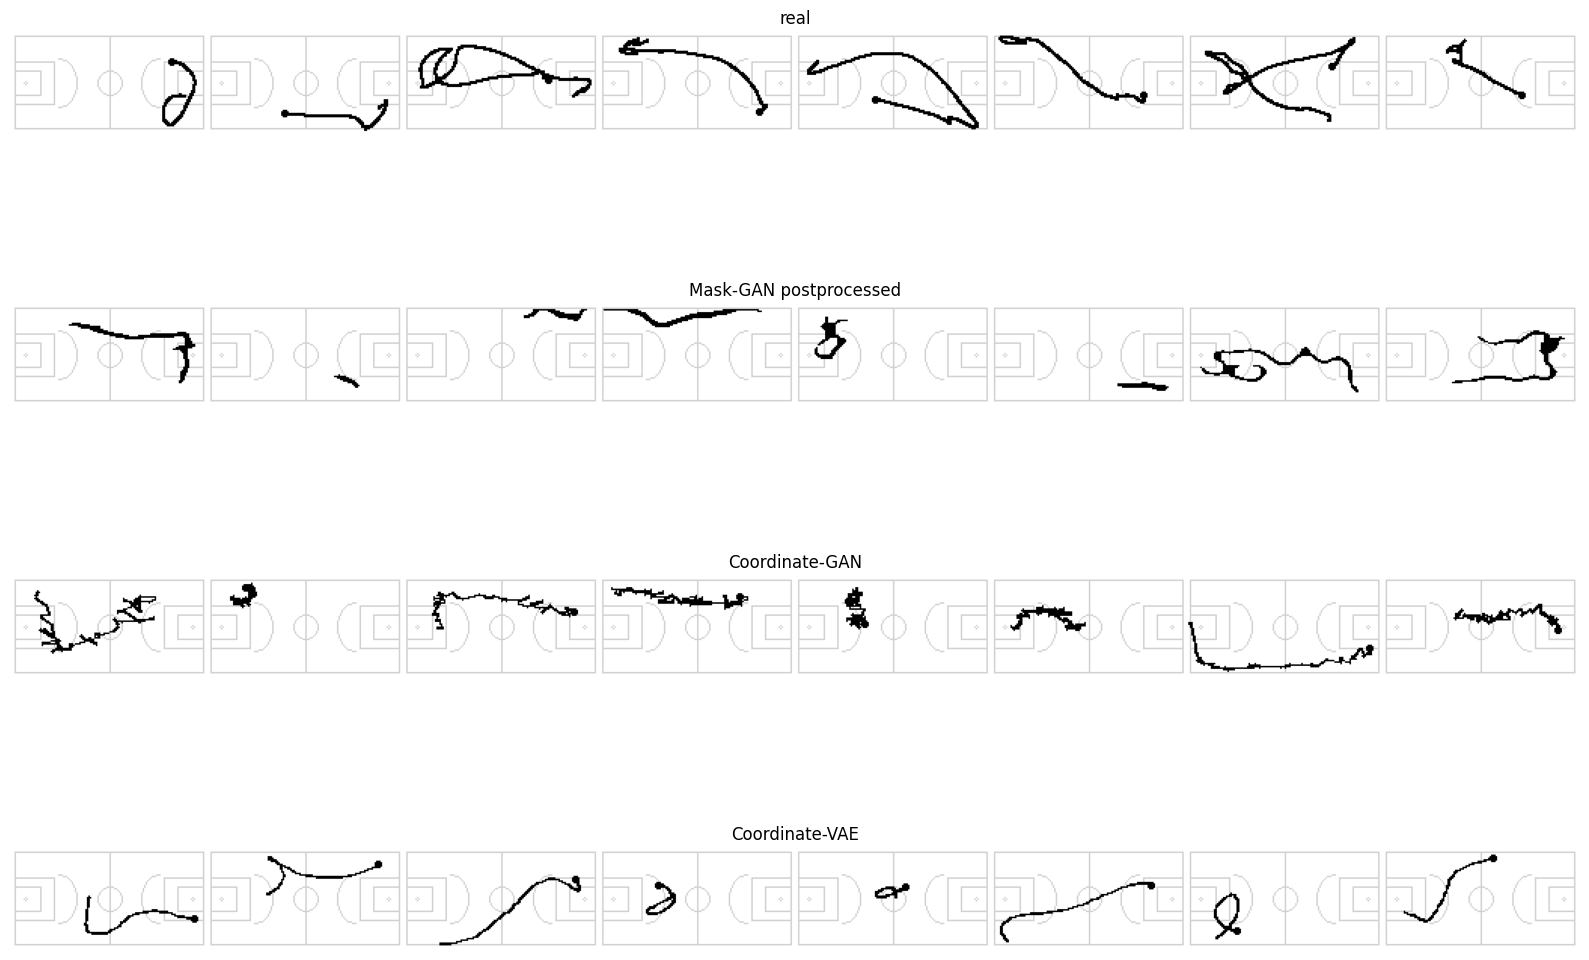

===== FINAL COORDINATE SUMMARY =====
Mask-GAN baseline генерирует пиксельные маски, но часто дает рваные линии.
Coordinate-GAN/VAE генерируют траектории как последовательности точек, затем линии рендерятся алгоритмически.
Это лучше соответствует природе задачи; FID не главный критерий для trajectory masks.
Coordinate-GAN coordinate metrics: {'mean_start_x': 0.2936643958091736, 'mean_start_y': 0.4064238667488098, 'mean_end_x': 0.6323411464691162, 'mean_end_y': 0.46287262439727783, 'path_length_mean': 2.273907423019409, 'path_length_std': 0.5239898562431335, 'displacement_mean': 0.4439944922924042, 'displacement_std': 0.27968618273735046, 'bbox_width_mean': 0.44382351636886597, 'bbox_height_mean': 0.3371194303035736, 'smoothness_mean': 0.046406280249357224, 'percent_out_of_bounds': 0.0}
Coordinate-VAE coordinate metrics: {'mean_start_x': 0.24758541584014893, 'mean_start_y': 0.43830442428588867, 'mean_end_x': 0.589950680732727, 'mean_end_y': 0.41243547201156616, 'path_length_mean': 0.9103

In [23]:
### ====================== Coordinate model generation and comparison ======================
def generated_points_from_vae(model, n=64):
    with torch.no_grad():
        z = torch.randn(n, COORD_LATENT_DIM, device=device)
        return model.decode(z).cpu().numpy()


def generated_points_from_gan(model, n=64):
    with torch.no_grad():
        z = torch.randn(n, COORD_Z_DIM, device=device)
        return model(z).cpu().numpy()

N_COORD_VIS = 64
coord_rows = []
real_coord_metrics = coordinate_metrics(X_test_coord[:min(len(X_test_coord), N_COORD_VIS)])
real_masks_for_compare = torch.stack([TrajectoryDataset(test_files)[i] for i in range(min(32, len(test_files)))])


def save_coord_comparison(fake_masks, filename, title, k=32):
    real_batch = real_masks_for_compare[:min(k, len(real_masks_for_compare), len(fake_masks))]
    fake_batch = fake_masks[:len(real_batch)]
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, batch, name in zip(axes, [real_batch, fake_batch], ["real masks + court template", title]):
        vis = overlay_masks_on_court(batch, kind="real")
        arr = make_grid(vis, nrow=4, padding=2, pad_value=1.0).clamp(0, 1)
        ax.imshow(arr.numpy().transpose(1, 2, 0))
        ax.set_title(name, fontsize=16)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(WORK / filename, dpi=120, bbox_inches="tight")
    plt.show()

if RUN_COORD_GAN and coord_gan is not None:
    coord_gan_points = generated_points_from_gan(coord_gan, N_COORD_VIS)
    coord_gan_masks = render_trajectory_batch(coord_gan_points)
    save_overlay_grid(coord_gan_masks[:32], WORK / "generated_coord_gan.png", nrow=8, kind="real")
    save_coord_comparison(coord_gan_masks, "compare_coord_gan.png", "Coordinate-GAN + court template")
    coord_rows += summarize_rendered_model("Coordinate-GAN", coord_gan_masks)
    (WORK / "coord_gan_metrics.json").write_text(json.dumps(coordinate_metrics(coord_gan_points), indent=2))
else:
    coord_gan_points = None; coord_gan_masks = None

if RUN_COORD_VAE and coord_vae is not None:
    coord_vae_points = generated_points_from_vae(coord_vae, N_COORD_VIS)
    coord_vae_masks = render_trajectory_batch(coord_vae_points)
    save_overlay_grid(coord_vae_masks[:32], WORK / "generated_coord_vae.png", nrow=8, kind="real")
    save_coord_comparison(coord_vae_masks, "compare_coord_vae.png", "Coordinate-VAE + court template")
    coord_rows += summarize_rendered_model("Coordinate-VAE", coord_vae_masks)
    (WORK / "coord_vae_metrics.json").write_text(json.dumps(coordinate_metrics(coord_vae_points), indent=2))
else:
    coord_vae_points = None; coord_vae_masks = None

comparison_rows = []
if RUN_MASK_GAN_BASELINE and fakes is not None and line_summary is not None:
    for split, model_name in [("fake_raw", "Mask-GAN raw"), ("fake_postprocessed", "Mask-GAN postprocessed")]:
        for metric in ["black_pixel_ratio", "connected_components_count", "fraction_of_broken_trajectories", "approximate_line_length", "bbox_width", "bbox_height"]:
            comparison_rows.append({"model": model_name, "metric": metric, "mean": metric_value(line_summary, split, metric), "std": float('nan')})
comparison_rows += coord_rows
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(WORK / "comparison_metrics.csv", index=False)
(WORK / "comparison_metrics.json").write_text(json.dumps(comparison_rows, indent=2))
display(comparison_df)

# all_models_comparison.png: real, Mask-GAN postprocessed if available, Coordinate-GAN, Coordinate-VAE
rows = [("real", overlay_masks_on_court(real_masks_for_compare[:8], kind="real"))]
if RUN_MASK_GAN_BASELINE and fakes is not None:
    rows.append(("Mask-GAN postprocessed", overlay_masks_on_court(fakes[:8], kind="fake_postprocessed")))
if coord_gan_masks is not None:
    rows.append(("Coordinate-GAN", overlay_masks_on_court(coord_gan_masks[:8], kind="real")))
if coord_vae_masks is not None:
    rows.append(("Coordinate-VAE", overlay_masks_on_court(coord_vae_masks[:8], kind="real")))
fig, axes = plt.subplots(len(rows), 1, figsize=(16, 3 * len(rows)))
if len(rows) == 1: axes = [axes]
for ax, (title, imgs) in zip(axes, rows):
    grid = make_grid(imgs, nrow=8, padding=2, pad_value=1.0).clamp(0, 1)
    ax.imshow(grid.permute(1,2,0).numpy()); ax.set_title(title); ax.axis('off')
fig.tight_layout(); fig.savefig(WORK / "all_models_comparison.png", dpi=140, bbox_inches="tight"); plt.show()

print("===== FINAL COORDINATE SUMMARY =====")
print("Mask-GAN baseline генерирует пиксельные маски, но часто дает рваные линии.")
print("Coordinate-GAN/VAE генерируют траектории как последовательности точек, затем линии рендерятся алгоритмически.")
print("Это лучше соответствует природе задачи; FID не главный критерий для trajectory masks.")
if coord_gan_points is not None:
    print("Coordinate-GAN coordinate metrics:", coordinate_metrics(coord_gan_points))
if coord_vae_points is not None:
    print("Coordinate-VAE coordinate metrics:", coordinate_metrics(coord_vae_points))
print("Artifacts:", WORK / "comparison_metrics.csv", WORK / "all_models_comparison.png")
